In [11]:
# ================================================================
# Stage 4 — TSC Application
# Small synthetic temporal network
#
# Part A:
#   microscopic pairwise-only nonlinear dynamics
#   full first-order structural closure audit
# ================================================================

from pathlib import Path
from itertools import combinations
from collections import Counter

import numpy as np
import pandas as pd
import sympy as sp
import networkx as nx
import matplotlib.pyplot as plt


# --------------------------------------------------------------
# Reproducibility
# --------------------------------------------------------------

SEED = 20260811
rng = np.random.default_rng(SEED)


# --------------------------------------------------------------
# Output directories
# --------------------------------------------------------------

DATA_DIR = Path("./data")
FIGURE_DIR = Path("./figures")

DATA_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)


# --------------------------------------------------------------
# System size
# --------------------------------------------------------------

N = 8
nodes = tuple(range(1, N + 1))

print("Stage 4 configuration loaded.")
print("N =", N)
print("seed =", SEED)

Stage 4 configuration loaded.
N = 8
seed = 20260811


Set up

In [12]:
# ================================================================
# Cell 1 — Updated microscopic pairwise network
# ================================================================

def canon_edge(i, j):
    return tuple(sorted((int(i), int(j))))


# --------------------------------------------------------------
# Outer 8-cycle
# --------------------------------------------------------------

outer_cycle_edges = [
    canon_edge(1, 2),
    canon_edge(2, 3),
    canon_edge(3, 4),
    canon_edge(4, 5),
    canon_edge(5, 6),
    canon_edge(6, 7),
    canon_edge(7, 8),
    canon_edge(8, 1),
]


# --------------------------------------------------------------
# Updated internal chords
# --------------------------------------------------------------

chord_edges = [
    canon_edge(1, 3),
    canon_edge(2, 4),
    canon_edge(3, 5),
    canon_edge(5, 7),
]


microscopic_edges = (
    outer_cycle_edges
    +
    chord_edges
)

microscopic_edge_set = set(microscopic_edges)

assert len(microscopic_edges) == 12
assert len(microscopic_edge_set) == 12


# --------------------------------------------------------------
# Fixed edge weights
# --------------------------------------------------------------

edge_weight_integer = {
    edge: int(rng.integers(800, 1201))
    for edge in microscopic_edges
}

edge_weight_float = {
    edge: value / 1000.0
    for edge, value in edge_weight_integer.items()
}

edge_weight_exact = {
    edge: sp.Rational(value, 1000)
    for edge, value in edge_weight_integer.items()
}


edge_ledger = pd.DataFrame([
    {
        "edge": f"{i}-{j}",
        "i": i,
        "j": j,
        "weight": edge_weight_float[(i, j)],
        "edge_type":
            "outer_cycle"
            if (i, j) in outer_cycle_edges
            else "chord"
    }
    for i, j in microscopic_edges
])

display(edge_ledger)

edge_ledger.to_csv(
    DATA_DIR / "stage4_microscopic_edges.csv",
    index=False
)

# Fixed RNG dedicated to the Stage-4 edge weights.
# Re-running this cell always reproduces exactly the same ledger.
weight_rng = np.random.default_rng(SEED)

edge_weight_integer = {
    edge: int(weight_rng.integers(800, 1201))
    for edge in microscopic_edges
}

print()
print("Number of microscopic edges:", len(microscopic_edges))
print("Updated edge weights frozen.")

,edge,i,j,weight,edge_type
0,1-2,1,2,1.006,outer_cycle
1,2-3,2,3,0.911,outer_cycle
2,3-4,3,4,1.105,outer_cycle
3,4-5,4,5,0.917,outer_cycle
4,5-6,5,6,1.177,outer_cycle
5,6-7,6,7,1.119,outer_cycle
6,7-8,7,8,0.917,outer_cycle
7,1-8,1,8,0.944,outer_cycle
8,1-3,1,3,1.026,chord
9,2-4,2,4,1.002,chord



Number of microscopic edges: 12
Updated edge weights frozen.


In [13]:
# ================================================================
# Cell 2 — Updated six-snapshot temporal protocol
# ================================================================

snapshot_edges = {

    "G1": [
        canon_edge(1, 2),
        canon_edge(3, 4),
        canon_edge(5, 6),
        canon_edge(7, 8),
    ],

    "G2": [
        canon_edge(2, 3),
        canon_edge(4, 5),
        canon_edge(6, 7),
        canon_edge(8, 1),
    ],

    "G3": [
        canon_edge(1, 3),
        canon_edge(2, 4),
        canon_edge(3, 5),
        canon_edge(5, 7),
    ],

    "G4": [
        canon_edge(1, 2),
        canon_edge(4, 5),
        canon_edge(7, 8),
        canon_edge(3, 5),
    ],

    "G5": [
        canon_edge(2, 3),
        canon_edge(5, 6),
        canon_edge(8, 1),
        canon_edge(5, 7),
    ],

    "G6": [
        canon_edge(3, 4),
        canon_edge(6, 7),
        canon_edge(1, 3),
        canon_edge(2, 4),
    ],
}


snapshot_names = tuple(snapshot_edges.keys())
n_snapshots = len(snapshot_names)

assert n_snapshots == 6


# --------------------------------------------------------------
# Basic validation
# --------------------------------------------------------------

for snapshot_name in snapshot_names:
    snapshot = snapshot_edges[snapshot_name]
    assert len(snapshot) == 4
    assert set(snapshot).issubset(microscopic_edge_set)


# --------------------------------------------------------------
# First and second traversal each cover the full graph once
# --------------------------------------------------------------

first_traversal = (
    snapshot_edges["G1"]
    + snapshot_edges["G2"]
    + snapshot_edges["G3"]
)

second_traversal = (
    snapshot_edges["G4"]
    + snapshot_edges["G5"]
    + snapshot_edges["G6"]
)

first_counts = Counter(first_traversal)
second_counts = Counter(second_traversal)

assert set(first_counts) == microscopic_edge_set
assert set(second_counts) == microscopic_edge_set

assert all(count == 1 for count in first_counts.values())
assert all(count == 1 for count in second_counts.values())


# --------------------------------------------------------------
# Full-window activation counts
# --------------------------------------------------------------

all_activations = [
    edge
    for snapshot_name in snapshot_names
    for edge in snapshot_edges[snapshot_name]
]

full_counts = Counter(all_activations)

assert set(full_counts) == microscopic_edge_set
assert all(count == 2 for count in full_counts.values())


activation_ledger = edge_ledger.copy()
activation_ledger["activation_count"] = [
    full_counts[canon_edge(i, j)]
    for i, j in zip(activation_ledger["i"], activation_ledger["j"])
]

activation_ledger["fraction_of_window_active"] = (
    activation_ledger["activation_count"] / n_snapshots
)

display(activation_ledger)

print("First traversal covers every edge exactly once: PASS")
print("Second traversal covers every edge exactly once: PASS")
print("Every edge appears exactly twice overall: PASS")
print()
print("Each edge is active for fraction", 2 / 6, "of one aggregation window.")

,edge,i,j,weight,edge_type,activation_count,fraction_of_window_active
0,1-2,1,2,1.006,outer_cycle,2,0.333333
1,2-3,2,3,0.911,outer_cycle,2,0.333333
2,3-4,3,4,1.105,outer_cycle,2,0.333333
3,4-5,4,5,0.917,outer_cycle,2,0.333333
4,5-6,5,6,1.177,outer_cycle,2,0.333333
5,6-7,6,7,1.119,outer_cycle,2,0.333333
6,7-8,7,8,0.917,outer_cycle,2,0.333333
7,1-8,1,8,0.944,outer_cycle,2,0.333333
8,1-3,1,3,1.026,chord,2,0.333333
9,2-4,2,4,1.002,chord,2,0.333333


First traversal covers every edge exactly once: PASS
Second traversal covers every edge exactly once: PASS
Every edge appears exactly twice overall: PASS

Each edge is active for fraction 0.3333333333333333 of one aggregation window.


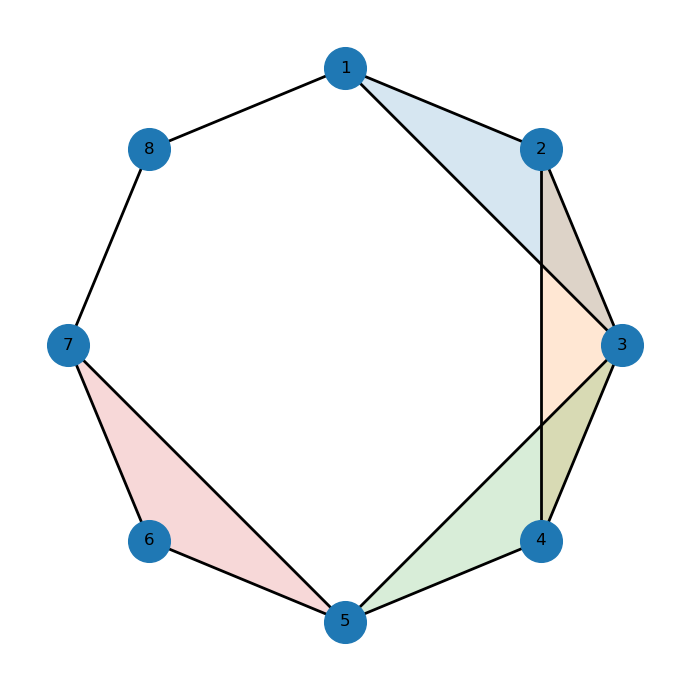

In [14]:
# ================================================================
# Cell 3 — Updated network figure
# ================================================================

G = nx.Graph()
G.add_nodes_from(nodes)
G.add_edges_from(microscopic_edges)


# --------------------------------------------------------------
# Fixed node positions
# --------------------------------------------------------------

angles = np.linspace(
    np.pi / 2,
    np.pi / 2 - 2 * np.pi,
    N,
    endpoint=False
)

pos = {
    node: (np.cos(angle), np.sin(angle))
    for node, angle in zip(nodes, angles)
}


# --------------------------------------------------------------
# Triangle list
# --------------------------------------------------------------

triangle_motifs = [
    (1, 2, 3),
    (2, 3, 4),
    (3, 4, 5),
    (5, 6, 7),
]


# --------------------------------------------------------------
# Draw
# --------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 7))

# Shade triangle motifs
for tri in triangle_motifs:
    polygon = np.array([pos[node] for node in tri])
    ax.fill(
        polygon[:, 0],
        polygon[:, 1],
        alpha=0.18
    )

# Draw edges
nx.draw_networkx_edges(
    G,
    pos,
    width=2.0,
    ax=ax
)

# Draw nodes
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=900,
    ax=ax
)

# Draw labels
nx.draw_networkx_labels(
    G,
    pos,
    font_size=12,
    ax=ax
)

ax.set_aspect("equal")
ax.axis("off")
plt.tight_layout()
plt.show()

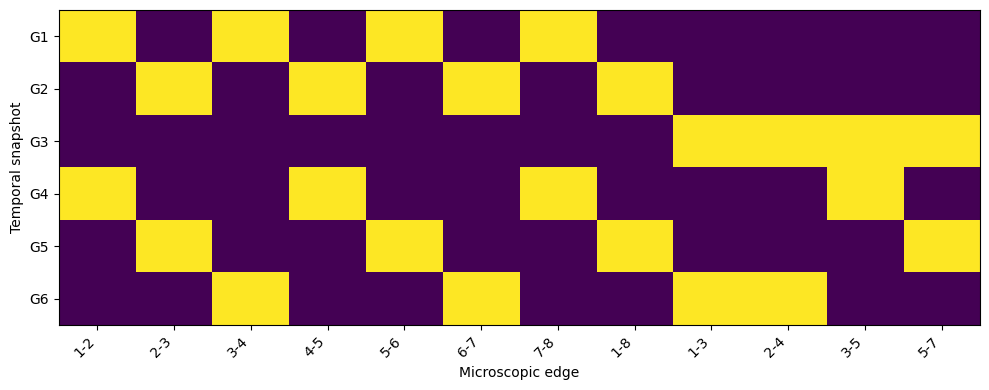

In [15]:
# ================================================================
# Cell 3b — Temporal activation matrix
# ================================================================

activation_matrix = np.zeros(
    (n_snapshots, len(microscopic_edges)),
    dtype=int
)

for snapshot_index, snapshot_name in enumerate(snapshot_names):
    active_edges = set(snapshot_edges[snapshot_name])

    for edge_index, edge in enumerate(microscopic_edges):
        activation_matrix[snapshot_index, edge_index] = int(edge in active_edges)


plt.figure(figsize=(10, 4))

plt.imshow(
    activation_matrix,
    aspect="auto"
)

plt.yticks(
    range(n_snapshots),
    snapshot_names
)

plt.xticks(
    range(len(microscopic_edges)),
    [f"{i}-{j}" for i, j in microscopic_edges],
    rotation=45,
    ha="right"
)

plt.xlabel("Microscopic edge")
plt.ylabel("Temporal snapshot")

plt.tight_layout()
plt.show()

In [16]:
# ================================================================
# Cell 4 — Nonlinear pairwise edge-local vector fields
# ================================================================

lambda_value = 0.5
lambda_exact = sp.Rational(1, 2)


# Symbolic node-state variables
x_symbols = sp.symbols(
    "x1:9"
)


def phi_symbolic(z):
    return (
        z
        +
        lambda_exact * z**2
    )


def phi_numeric(z):
    return (
        z
        +
        lambda_value * z**2
    )


# --------------------------------------------------------------
# Symbolic edge-local vector field
#
# For edge (i,j):
#
# dx_i/dt = w_ij [phi(x_j) - phi(x_i)]
# dx_j/dt = -dx_i/dt
# --------------------------------------------------------------

def symbolic_edge_field(edge):

    i, j = edge

    w = edge_weight_exact[
        edge
    ]

    vector_field = sp.zeros(
        N,
        1
    )

    flow_ij = (
        w
        *
        (
            phi_symbolic(
                x_symbols[j - 1]
            )

            -

            phi_symbolic(
                x_symbols[i - 1]
            )
        )
    )


    vector_field[
        i - 1
    ] = flow_ij

    vector_field[
        j - 1
    ] = -flow_ij


    return vector_field


symbolic_edge_fields = {
    edge:
        symbolic_edge_field(edge)

    for edge
    in microscopic_edges
}


print(
    "Constructed",
    len(symbolic_edge_fields),
    "microscopic nonlinear edge vector fields."
)


# --------------------------------------------------------------
# Conservation check
# --------------------------------------------------------------

for edge, vector_field in symbolic_edge_fields.items():

    assert sp.simplify(
        sum(vector_field)
    ) == 0


print(
    "Each edge-local flow conserves total state: PASS"
)

Constructed 12 microscopic nonlinear edge vector fields.
Each edge-local flow conserves total state: PASS


In [17]:
# ================================================================
# Cell 5 — Snapshot generators and zeroth-order effective field
# ================================================================

snapshot_fields = {}


for snapshot_name in snapshot_names:

    total_field = sp.zeros(
        N,
        1
    )

    for edge in snapshot_edges[
        snapshot_name
    ]:

        total_field += (
            symbolic_edge_fields[
                edge
            ]
        )

    snapshot_fields[
        snapshot_name
    ] = total_field


# --------------------------------------------------------------
# Zeroth-order effective generator
# --------------------------------------------------------------

F0 = (
    sum(
        snapshot_fields.values(),
        sp.zeros(N, 1)
    )

    / n_snapshots
)


# Expected aggregate from equal exposure
F0_expected = (

    sum(
        symbolic_edge_fields.values(),
        sp.zeros(N, 1)
    )

    / 3
)


F0_difference = sp.Matrix([
    sp.simplify(
        F0[i]
        -
        F0_expected[i]
    )

    for i in range(N)
])


assert all(
    entry == 0
    for entry
    in F0_difference
)


print(
    "Constructed six snapshot generators."
)

print(
    "F^(0) equals 1/3 of the full microscopic aggregate: PASS"
)

print()

print(
    "This confirms that unequal intermediate exposure does not"
)

print(
    "alter the full-window leading aggregate."
)

Constructed six snapshot generators.
F^(0) equals 1/3 of the full microscopic aggregate: PASS

This confirms that unequal intermediate exposure does not
alter the full-window leading aggregate.


In [18]:
# ================================================================
# Cell 6 — First-order BCH / Lie closure
# ================================================================

def lie_bracket(X, Y):
    """
    Vector-field Lie bracket:

        [X,Y] = DY · X - DX · Y
    """

    JX = X.jacobian(
        x_symbols
    )

    JY = Y.jacobian(
        x_symbols
    )

    return (
        JY * X
        -
        JX * Y
    )


forward_fields = [
    snapshot_fields[
        snapshot_name
    ]

    for snapshot_name
    in snapshot_names
]


# --------------------------------------------------------------
# First-order BCH coefficient
# --------------------------------------------------------------

F1_forward_sum = sp.zeros(
    N,
    1
)


for s in range(
    n_snapshots
):

    for r in range(s):

        F1_forward_sum += lie_bracket(
            forward_fields[r],
            forward_fields[s]
        )


F1_forward = sp.Matrix([
    sp.expand(
        component / 72
    )

    for component
    in F1_forward_sum
])


# --------------------------------------------------------------
# Reverse chronology
# --------------------------------------------------------------

reverse_fields = list(
    reversed(
        forward_fields
    )
)


F1_reverse_sum = sp.zeros(
    N,
    1
)


for s in range(
    n_snapshots
):

    for r in range(s):

        F1_reverse_sum += lie_bracket(
            reverse_fields[r],
            reverse_fields[s]
        )


F1_reverse = sp.Matrix([
    sp.expand(
        component / 72
    )

    for component
    in F1_reverse_sum
])


# --------------------------------------------------------------
# Exact chronology-reversal check
# --------------------------------------------------------------

reverse_check = [

    sp.simplify(
        F1_reverse[i]
        +
        F1_forward[i]
    )

    for i in range(N)
]


assert all(
    entry == 0
    for entry
    in reverse_check
)


print(
    "First-order temporal closure constructed."
)

print(
    "Forward / reverse first-order antisymmetry: PASS"
)

print()

print(
    "F_eff^F = F0 + epsilon F1 + O(epsilon^2)"
)

print(
    "F_eff^R = F0 - epsilon F1 + O(epsilon^2)"
)

First-order temporal closure constructed.
Forward / reverse first-order antisymmetry: PASS

F_eff^F = F0 + epsilon F1 + O(epsilon^2)
F_eff^R = F0 - epsilon F1 + O(epsilon^2)


In [19]:
# ================================================================
# Cell 7 — Support-resolved oracle closure audit
# ================================================================

def vector_field_term_ledger(
    vector_field,
    order_label
):

    rows = []


    for output_node, expression in enumerate(
        vector_field,
        start=1
    ):

        polynomial = sp.Poly(
            sp.expand(
                expression
            ),
            *x_symbols
        )


        for monomial_powers, coefficient in polynomial.terms():

            if coefficient == 0:
                continue


            variable_nodes = {

                node_index

                for node_index, power
                in enumerate(
                    monomial_powers,
                    start=1
                )

                if power > 0
            }


            # Structural support includes the node whose
            # dynamical equation contains the term.
            support = tuple(
                sorted(
                    variable_nodes
                    |
                    {output_node}
                )
            )


            rows.append({

                "order":
                    order_label,

                "output_node":
                    output_node,

                "degree":
                    int(
                        sum(
                            monomial_powers
                        )
                    ),

                "monomial_powers":
                    monomial_powers,

                "monomial":
                    str(
                        np.prod([
                            (
                                x_symbols[k] **
                                monomial_powers[k]
                            )

                            for k
                            in range(N)
                        ])
                    ),

                "coefficient_exact":
                    coefficient,

                "coefficient":
                    float(
                        coefficient
                    ),

                "support":
                    support,

                "support_size":
                    len(
                        support
                    )
            })


    return pd.DataFrame(
        rows
    )


F0_term_ledger = (
    vector_field_term_ledger(
        F0,
        "O(1)"
    )
)


F1_term_ledger = (
    vector_field_term_ledger(
        F1_forward,
        "O(epsilon)"
    )
)


print(
    "F0 maximum support size:",
    F0_term_ledger[
        "support_size"
    ].max()
)

print(
    "F1 maximum support size:",
    F1_term_ledger[
        "support_size"
    ].max()
)

print()

display(
    F0_term_ledger.groupby(
        [
            "support_size",
            "degree"
        ]
    ).size().rename(
        "number_of_terms"
    ).reset_index()
)

display(
    F1_term_ledger.groupby(
        [
            "support_size",
            "degree"
        ]
    ).size().rename(
        "number_of_terms"
    ).reset_index()
)

F0 maximum support size: 2
F1 maximum support size: 3



,support_size,degree,number_of_terms
0,1,1,8
1,1,2,8
2,2,1,24
3,2,2,24


,support_size,degree,number_of_terms
0,2,1,44
1,2,2,68
2,2,3,48
3,3,2,33
4,3,3,38


4A

In [20]:
# ================================================================
# Cell 8 — Structural closure summary
# ================================================================

def build_support_ledger(
    term_ledger
):

    rows = []


    for (
        support,
        support_size
    ), group in term_ledger.groupby(
        [
            "support",
            "support_size"
        ]
    ):

        coefficient_squared_sum = sum(

            coefficient**2

            for coefficient
            in group[
                "coefficient_exact"
            ]
        )


        coefficient_l2 = float(
            sp.sqrt(
                coefficient_squared_sum
            )
        )


        rows.append({

            "support":
                support,

            "support_size":
                support_size,

            "coefficient_l2":
                coefficient_l2,

            "number_of_terms":
                len(group),

            "max_degree":
                int(
                    group[
                        "degree"
                    ].max()
                )
        })


    return pd.DataFrame(
        rows
    )


F0_support_ledger = (
    build_support_ledger(
        F0_term_ledger
    )
)


F1_support_ledger = (
    build_support_ledger(
        F1_term_ledger
    )
)


# --------------------------------------------------------------
# Pairwise O(epsilon) sectors
# --------------------------------------------------------------

F1_pair_supports = (
    F1_support_ledger[
        F1_support_ledger[
            "support_size"
        ]
        ==
        2
    ]
    .copy()
)


F1_pair_supports[
    "microscopic_edge"
] = [

    tuple(support)
    in microscopic_edge_set

    for support
    in F1_pair_supports[
        "support"
    ]
]


F1_pair_supports[
    "structural_class"
] = np.where(

    F1_pair_supports[
        "microscopic_edge"
    ],

    "correction_on_existing_edge",

    "phantom_edge"
)


# --------------------------------------------------------------
# Triadic O(epsilon) sectors
# --------------------------------------------------------------

def number_of_internal_micro_edges(
    support
):

    return sum(

        canon_edge(i, j)
        in microscopic_edge_set

        for i, j
        in combinations(
            support,
            2
        )
    )


F1_triad_supports = (
    F1_support_ledger[
        F1_support_ledger[
            "support_size"
        ]
        ==
        3
    ]
    .copy()
)


F1_triad_supports[
    "number_of_internal_micro_edges"
] = [

    number_of_internal_micro_edges(
        support
    )

    for support
    in F1_triad_supports[
        "support"
    ]
]


F1_triad_supports[
    "motif_class"
] = F1_triad_supports[
    "number_of_internal_micro_edges"
].map({

    3: "triangle",
    2: "wedge",
    1: "single_edge",
    0: "disconnected"
})


# --------------------------------------------------------------
# Display
# --------------------------------------------------------------

print(
    "O(epsilon) pair supports:",
    len(
        F1_pair_supports
    )
)

print(
    "O(epsilon) phantom pair supports:",
    (
        F1_pair_supports[
            "structural_class"
        ]
        ==
        "phantom_edge"
    ).sum()
)

print(
    "O(epsilon) triadic supports:",
    len(
        F1_triad_supports
    )
)

print()


print(
    "PHANTOM PAIRWISE SUPPORTS"
)

display(

    F1_pair_supports[
        F1_pair_supports[
            "structural_class"
        ]
        ==
        "phantom_edge"
    ]
    .sort_values(
        "coefficient_l2",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "TRIADIC SUPPORTS"
)

display(

    F1_triad_supports
    .sort_values(
        "coefficient_l2",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# --------------------------------------------------------------
# Save oracle ledgers
# --------------------------------------------------------------

F0_term_ledger.to_csv(
    DATA_DIR / "stage4_F0_term_ledger.csv",
    index=False
)

F1_term_ledger.to_csv(
    DATA_DIR / "stage4_F1_term_ledger.csv",
    index=False
)

F1_pair_supports.to_csv(
    DATA_DIR / "stage4_F1_pair_supports.csv",
    index=False
)

F1_triad_supports.to_csv(
    DATA_DIR / "stage4_F1_triad_supports.csv",
    index=False
)


print()
print("Oracle closure ledgers saved.")

O(epsilon) pair supports: 22
O(epsilon) phantom pair supports: 10
O(epsilon) triadic supports: 15

PHANTOM PAIRWISE SUPPORTS


,support,support_size,coefficient_l2,number_of_terms,max_degree,microscopic_edge,structural_class
0,"(6, 8)",2,0.045068,4,2,False,phantom_edge
1,"(3, 8)",2,0.042539,4,2,False,phantom_edge
2,"(2, 8)",2,0.041710,4,2,False,phantom_edge
3,"(4, 7)",2,0.041524,4,2,False,phantom_edge
4,"(5, 8)",2,0.041524,4,2,False,phantom_edge
5,"(2, 5)",2,0.040356,4,2,False,phantom_edge
6,"(1, 7)",2,0.038020,4,2,False,phantom_edge
7,"(3, 7)",2,0.024158,4,2,False,phantom_edge
8,"(1, 5)",2,0.024041,4,2,False,phantom_edge
9,"(1, 4)",2,0.019375,4,2,False,phantom_edge


TRIADIC SUPPORTS


,support,support_size,coefficient_l2,number_of_terms,max_degree,number_of_internal_micro_edges,motif_class
0,"(1, 2, 3)",3,0.083589,9,3,3,triangle
1,"(5, 6, 7)",3,0.072729,7,3,3,triangle
2,"(2, 3, 4)",3,0.054575,7,3,3,triangle
3,"(6, 7, 8)",3,0.045068,4,3,2,wedge
4,"(1, 2, 4)",3,0.044272,4,3,2,wedge
5,"(1, 3, 8)",3,0.042539,4,3,2,wedge
6,"(1, 2, 8)",3,0.041710,4,3,2,wedge
7,"(5, 7, 8)",3,0.041524,4,3,2,wedge
8,"(4, 5, 7)",3,0.041524,4,3,2,wedge
9,"(2, 4, 5)",3,0.040356,4,3,2,wedge



Oracle closure ledgers saved.


In [21]:
# ================================================================
# Cell 9 — Inspect representative first-order structural sectors
# ================================================================

def monomial_from_powers(powers):
    """Reconstruct a SymPy monomial from exponent tuple."""
    monomial = sp.Integer(1)

    for x, power in zip(x_symbols, powers):
        monomial *= x ** int(power)

    return monomial


def structural_support(output_node, powers):
    """
    Minimal structural support of one vector-field monomial.

    Includes:
      - the node whose dynamical equation contains the term
      - every state variable appearing in the monomial
    """
    variable_nodes = {
        idx
        for idx, power in enumerate(powers, start=1)
        if power > 0
    }

    return tuple(
        sorted(variable_nodes | {output_node})
    )


def extract_support_sector(vector_field, target_support):
    """
    Extract all monomial terms belonging exactly to target_support.

    Returns:
      sector_field : N-component symbolic vector field
      ledger       : term-by-term DataFrame
    """

    target_support = tuple(sorted(target_support))

    sector_field = sp.zeros(N, 1)
    rows = []

    for output_node, expression in enumerate(vector_field, start=1):

        poly = sp.Poly(
            sp.expand(expression),
            *x_symbols
        )

        for powers, coefficient in poly.terms():

            if coefficient == 0:
                continue

            support = structural_support(
                output_node,
                powers
            )

            if support != target_support:
                continue

            monomial = monomial_from_powers(
                powers
            )

            term = coefficient * monomial

            sector_field[
                output_node - 1
            ] += term

            rows.append({
                "output_node": output_node,
                "degree": int(sum(powers)),
                "monomial": monomial,
                "coefficient_exact": coefficient,
                "coefficient_float": float(coefficient),
                "term": term,
            })

    sector_field = sp.Matrix([
        sp.factor(sp.expand(component))
        for component in sector_field
    ])

    ledger = pd.DataFrame(rows)

    if len(ledger) > 0:
        ledger = (
            ledger
            .sort_values(
                ["output_node", "degree", "monomial"],
                key=lambda col: col.astype(str)
                if col.name == "monomial"
                else col
            )
            .reset_index(drop=True)
        )

    return sector_field, ledger


def show_support_sector(vector_field, target_support, title=None):

    target_support = tuple(sorted(target_support))

    sector_field, ledger = extract_support_sector(
        vector_field,
        target_support
    )

    print("=" * 70)

    if title is not None:
        print(title)

    print("Support:", target_support)
    print("Number of monomial terms:", len(ledger))

    if len(ledger) > 0:
        print(
            "Maximum polynomial degree:",
            ledger["degree"].max()
        )

    print()

    if len(ledger) > 0:
        display(
            ledger[
                [
                    "output_node",
                    "degree",
                    "monomial",
                    "coefficient_exact",
                    "coefficient_float",
                ]
            ]
        )

    print("Sector vector field:")
    print()

    for node in target_support:

        expression = sp.factor(
            sector_field[node - 1]
        )

        print(
            f"dx{node}/dt =",
            expression
        )

    print()

    return sector_field, ledger


# --------------------------------------------------------------
# Representative sectors
# --------------------------------------------------------------

F1_68, ledger_68 = show_support_sector(
    F1_forward,
    (6, 8),
    title="A. Peripheral phantom pair sector"
)


F1_123, ledger_123 = show_support_sector(
    F1_forward,
    (1, 2, 3),
    title="B. Strong triangle triadic sector"
)


F1_124, ledger_124 = show_support_sector(
    F1_forward,
    (1, 2, 4),
    title="C. Overlapping-core wedge triadic sector"
)

A. Peripheral phantom pair sector
Support: (6, 8)
Number of monomial terms: 4
Maximum polynomial degree: 2



,output_node,degree,monomial,coefficient_exact,coefficient_float
0,6,1,x8,342041/12000000,0.028503
1,6,2,x8**2,342041/24000000,0.014252
2,8,1,x6,-342041/12000000,-0.028503
3,8,2,x6**2,-342041/24000000,-0.014252


Sector vector field:

dx6/dt = 342041*x8*(x8 + 2)/24000000
dx8/dt = -342041*x6*(x6 + 2)/24000000

B. Strong triangle triadic sector
Support: (1, 2, 3)
Number of monomial terms: 9
Maximum polynomial degree: 3



,output_node,degree,monomial,coefficient_exact,coefficient_float
0,1,2,x2*x3,911/1800000,0.000506
1,1,3,x2**2*x3,51927/4000000,0.012982
2,1,3,x2*x3**2,-458233/36000000,-0.012729
3,2,2,x1*x3,-109269/2000000,-0.054635
4,2,3,x1**2*x3,-51927/4000000,-0.012982
5,2,3,x1*x3**2,-28671/2000000,-0.014335
6,3,2,x1*x2,974311/18000000,0.054128
7,3,3,x1**2*x2,458233/36000000,0.012729
8,3,3,x1*x2**2,28671/2000000,0.014335


Sector vector field:

dx1/dt = 911*x2*x3*(513*x2 - 503*x3 + 20)/36000000
dx2/dt = -57*x1*x3*(911*x1 + 1006*x3 + 3834)/4000000
dx3/dt = 503*x1*x2*(911*x1 + 1026*x2 + 3874)/36000000

C. Overlapping-core wedge triadic sector
Support: (1, 2, 4)
Number of monomial terms: 4
Maximum polynomial degree: 3



,output_node,degree,monomial,coefficient_exact,coefficient_float
0,1,2,x2*x4,-84001/3000000,-0.028
1,1,3,x2*x4**2,-84001/6000000,-0.014
2,4,2,x1*x2,84001/3000000,0.028
3,4,3,x1**2*x2,84001/6000000,0.014


Sector vector field:

dx1/dt = -84001*x2*x4*(x4 + 2)/6000000
dx2/dt = 0
dx4/dt = 84001*x1*x2*(x1 + 2)/6000000



In [22]:
# ================================================================
# Cell 10 — Generic support-resolved polynomial dictionary
# ================================================================

from itertools import combinations_with_replacement


def powers_from_indices(indices):
    """
    Convert repeated variable indices into exponent tuple.

    Example:
        (0, 1, 1) -> x1 * x2^2
    """

    powers = [0] * N

    for idx in indices:
        powers[idx] += 1

    return tuple(powers)


dictionary_rows = []


for output_node in nodes:

    for degree in (1, 2, 3):

        for variable_indices in combinations_with_replacement(
            range(N),
            degree
        ):

            powers = powers_from_indices(
                variable_indices
            )

            variable_nodes = {
                idx + 1
                for idx, power
                in enumerate(powers)
                if power > 0
            }

            support = tuple(
                sorted(
                    variable_nodes
                    |
                    {output_node}
                )
            )

            support_size = len(support)

            # Stage-4A dictionary:
            # retain at most triadic structural support
            if support_size > 3:
                continue

            monomial = monomial_from_powers(
                powers
            )

            dictionary_rows.append({
                "basis_id": len(dictionary_rows),
                "output_node": output_node,
                "degree": degree,
                "powers": powers,
                "monomial": monomial,
                "support": support,
                "support_size": support_size,
            })


dictionary_ledger = pd.DataFrame(
    dictionary_rows
)


print(
    "Total dictionary size:",
    len(dictionary_ledger)
)

print()

display(
    dictionary_ledger.groupby(
        [
            "support_size",
            "degree"
        ]
    )
    .size()
    .rename(
        "number_of_basis_functions"
    )
    .reset_index()
)


print()
print("Basis functions by structural sector:")

display(
    dictionary_ledger.groupby(
        "support_size"
    )
    .size()
    .rename(
        "number_of_basis_functions"
    )
    .reset_index()
)


# --------------------------------------------------------------
# Expected dimensions
# --------------------------------------------------------------

n_onebody_expected = 24
n_pair_expected = 336
n_triad_expected = 672
n_total_expected = 1032


counts_by_support_size = (
    dictionary_ledger
    .groupby("support_size")
    .size()
    .to_dict()
)


assert counts_by_support_size[1] == n_onebody_expected
assert counts_by_support_size[2] == n_pair_expected
assert counts_by_support_size[3] == n_triad_expected

assert len(dictionary_ledger) == n_total_expected


print()
print("Dictionary dimension checks: PASS")

Total dictionary size: 1032



,support_size,degree,number_of_basis_functions
0,1,1,8
1,1,2,8
2,1,3,8
3,2,1,56
4,2,2,112
5,2,3,168
6,3,2,168
7,3,3,504



Basis functions by structural sector:


,support_size,number_of_basis_functions
0,1,24
1,2,336
2,3,672



Dictionary dimension checks: PASS


In [23]:
# ================================================================
# Cell 11 — Oracle coverage audit
# ================================================================

dictionary_keys = {
    (
        int(row.output_node),
        tuple(row.powers)
    )
    for row in dictionary_ledger.itertuples()
}


def audit_oracle_coverage(
    term_ledger,
    label
):

    oracle_keys = {
        (
            int(row.output_node),
            tuple(row.monomial_powers)
        )
        for row in term_ledger.itertuples()
    }

    missing = (
        oracle_keys
        -
        dictionary_keys
    )

    print(
        f"{label}:"
    )

    print(
        "  number of active oracle basis directions =",
        len(oracle_keys)
    )

    print(
        "  missing from dictionary =",
        len(missing)
    )

    if len(missing) > 0:

        print(
            "  MISSING KEYS:"
        )

        for item in sorted(missing):
            print("   ", item)

    else:

        print(
            "  complete coverage: PASS"
        )

    print()

    return oracle_keys, missing


F0_oracle_keys, F0_missing = (
    audit_oracle_coverage(
        F0_term_ledger,
        "F0"
    )
)


F1_oracle_keys, F1_missing = (
    audit_oracle_coverage(
        F1_term_ledger,
        "F1"
    )
)


assert len(F0_missing) == 0
assert len(F1_missing) == 0


oracle_union = (
    F0_oracle_keys
    |
    F1_oracle_keys
)


print(
    "Total dictionary directions:",
    len(dictionary_keys)
)

print(
    "Active in F0 or F1:",
    len(oracle_union)
)

print(
    "Inactive candidate directions:",
    len(dictionary_keys - oracle_union)
)

print()

print(
    "Full first-order oracle is contained in the generic dictionary: PASS"
)

F0:
  number of active oracle basis directions = 64
  missing from dictionary = 0
  complete coverage: PASS

F1:
  number of active oracle basis directions = 231
  missing from dictionary = 0
  complete coverage: PASS

Total dictionary directions: 1032
Active in F0 or F1: 247
Inactive candidate directions: 785

Full first-order oracle is contained in the generic dictionary: PASS


In [24]:
# ================================================================
# Cell 12 — Numerical identifiability of the generic dictionary
# ================================================================

N_IDENT = 3000
IDENT_SEED = SEED + 1

ident_rng = np.random.default_rng(
    IDENT_SEED
)

X_ident = ident_rng.uniform(
    -0.5,
    0.5,
    size=(N_IDENT, N)
)


# --------------------------------------------------------------
# Evaluate one monomial on a state matrix
# --------------------------------------------------------------

def evaluate_monomial_powers(
    X,
    powers
):
    """
    X:
        shape (n_samples, N)

    powers:
        exponent tuple of length N
    """

    values = np.ones(
        X.shape[0],
        dtype=float
    )

    for j, power in enumerate(powers):

        if power > 0:
            values *= X[:, j] ** power

    return values


# --------------------------------------------------------------
# Per-output-node feature matrices
# --------------------------------------------------------------

identifiability_rows = []

feature_matrices = {}


for output_node in nodes:

    node_dictionary = (
        dictionary_ledger[
            dictionary_ledger[
                "output_node"
            ]
            ==
            output_node
        ]
        .copy()
        .reset_index(drop=True)
    )

    n_features = len(
        node_dictionary
    )

    Theta = np.column_stack([
        evaluate_monomial_powers(
            X_ident,
            tuple(row.powers)
        )

        for row
        in node_dictionary.itertuples()
    ])

    feature_matrices[
        output_node
    ] = Theta


    # ----------------------------------------------------------
    # Raw singular values
    # ----------------------------------------------------------

    singular_values = np.linalg.svd(
        Theta,
        compute_uv=False
    )

    rank_raw = np.linalg.matrix_rank(
        Theta
    )

    condition_raw = (
        singular_values[0]
        /
        singular_values[-1]
    )


    # ----------------------------------------------------------
    # Column-normalized matrix
    #
    # This removes trivial conditioning differences caused only
    # by different polynomial amplitudes (x, x^2, x^3).
    # ----------------------------------------------------------

    column_norms = np.linalg.norm(
        Theta,
        axis=0
    )

    assert np.all(
        column_norms > 0
    )

    Theta_normalized = (
        Theta
        /
        column_norms
    )

    normalized_singular_values = np.linalg.svd(
        Theta_normalized,
        compute_uv=False
    )

    rank_normalized = np.linalg.matrix_rank(
        Theta_normalized
    )

    condition_normalized = (
        normalized_singular_values[0]
        /
        normalized_singular_values[-1]
    )


    identifiability_rows.append({

        "output_node":
            output_node,

        "n_samples":
            N_IDENT,

        "n_features":
            n_features,

        "rank_raw":
            rank_raw,

        "rank_normalized":
            rank_normalized,

        "sigma_max_raw":
            singular_values[0],

        "sigma_min_raw":
            singular_values[-1],

        "condition_raw":
            condition_raw,

        "sigma_max_normalized":
            normalized_singular_values[0],

        "sigma_min_normalized":
            normalized_singular_values[-1],

        "condition_normalized":
            condition_normalized,
    })


identifiability_ledger = pd.DataFrame(
    identifiability_rows
)


display(
    identifiability_ledger
)


# --------------------------------------------------------------
# Acceptance tests
# --------------------------------------------------------------

assert all(
    identifiability_ledger[
        "n_features"
    ]
    ==
    129
)

assert all(
    identifiability_ledger[
        "rank_raw"
    ]
    ==
    129
)

assert all(
    identifiability_ledger[
        "rank_normalized"
    ]
    ==
    129
)


print()
print(
    "All 8 output-node dictionaries have full numerical rank: PASS"
)

print()

print(
    "Maximum normalized condition number:",
    identifiability_ledger[
        "condition_normalized"
    ].max()
)

print(
    "Minimum normalized singular value:",
    identifiability_ledger[
        "sigma_min_normalized"
    ].min()
)

,output_node,n_samples,n_features,rank_raw,rank_normalized,sigma_max_raw,sigma_min_raw,condition_raw,sigma_max_normalized,sigma_min_normalized,condition_normalized
0,1,3000,129,129,129,17.392834,0.918238,18.941532,2.622911,0.214767,12.212817
1,2,3000,129,129,129,17.392719,0.920994,18.884716,2.622369,0.215757,12.154275
2,3,3000,129,129,129,17.392478,0.919975,18.905377,2.620879,0.215443,12.165081
3,4,3000,129,129,129,17.392745,0.922124,18.861621,2.621944,0.216052,12.135704
4,5,3000,129,129,129,17.392658,0.921812,18.867910,2.622001,0.215784,12.151045
5,6,3000,129,129,129,17.392428,0.917759,18.950971,2.619905,0.214991,12.186097
6,7,3000,129,129,129,17.392512,0.916231,18.982672,2.620782,0.215951,12.135989
7,8,3000,129,129,129,17.392293,0.923117,18.840841,2.619443,0.215432,12.159040



All 8 output-node dictionaries have full numerical rank: PASS

Maximum normalized condition number: 12.212817254254418
Minimum normalized singular value: 0.2147670783158075


In [25]:
# ================================================================
# Cell 13 — Multi-epsilon dataset configuration
# ================================================================

EPS_VALUES = np.array([
    0.005,
    0.0075,
    0.010,
    0.015,
    0.020,
    0.030,
    0.040,
    0.060,
    0.080,
    0.100,
    0.120,
], dtype=float)


N_TRAIN = 3000
N_TEST = 1000
N_TOTAL = N_TRAIN + N_TEST

DATA_SEED = SEED + 2

data_rng = np.random.default_rng(
    DATA_SEED
)


# --------------------------------------------------------------
# Same initial states for every epsilon and both chronologies
# --------------------------------------------------------------

X0_all = data_rng.uniform(
    -0.5,
    0.5,
    size=(N_TOTAL, N)
)


X0_train = X0_all[:N_TRAIN]
X0_test = X0_all[N_TRAIN:]


forward_order = tuple(
    snapshot_names
)

reverse_order = tuple(
    reversed(snapshot_names)
)


print("epsilon values:")
print(EPS_VALUES)

print()
print("Number of epsilon values:", len(EPS_VALUES))
print("Training states:", N_TRAIN)
print("Test states:", N_TEST)

print()
print("Forward protocol:", forward_order)
print("Reverse protocol:", reverse_order)

epsilon values:
[0.005  0.0075 0.01   0.015  0.02   0.03   0.04   0.06   0.08   0.1
 0.12  ]

Number of epsilon values: 11
Training states: 3000
Test states: 1000

Forward protocol: ('G1', 'G2', 'G3', 'G4', 'G5', 'G6')
Reverse protocol: ('G6', 'G5', 'G4', 'G3', 'G2', 'G1')


In [26]:
# ================================================================
# Cell 14 — Vectorized temporal evolution
# ================================================================

RK4_MAX_STEP = 1.0e-3


def phi_batch(x):
    return (
        x
        +
        lambda_value * x**2
    )


def snapshot_rhs_batch(
    X,
    snapshot_name
):
    """
    Evaluate one snapshot vector field on a batch of states.

    X shape:
        (n_samples, N)
    """

    dX = np.zeros_like(
        X,
        dtype=float
    )

    for edge in snapshot_edges[
        snapshot_name
    ]:

        i, j = edge

        # Convert 1-based node labels to array indices
        ii = i - 1
        jj = j - 1

        w = edge_weight_float[
            edge
        ]

        flow = (
            w
            *
            (
                phi_batch(X[:, jj])
                -
                phi_batch(X[:, ii])
            )
        )

        dX[:, ii] += flow
        dX[:, jj] -= flow

    return dX


def rk4_snapshot_batch(
    X,
    snapshot_name,
    duration,
    max_step=RK4_MAX_STEP
):
    """
    Integrate one snapshot using vectorized fixed-step RK4.
    """

    n_steps = max(
        1,
        int(
            np.ceil(
                abs(duration)
                /
                max_step
            )
        )
    )

    h = duration / n_steps

    Y = X.copy()

    for _ in range(n_steps):

        k1 = snapshot_rhs_batch(
            Y,
            snapshot_name
        )

        k2 = snapshot_rhs_batch(
            Y + 0.5 * h * k1,
            snapshot_name
        )

        k3 = snapshot_rhs_batch(
            Y + 0.5 * h * k2,
            snapshot_name
        )

        k4 = snapshot_rhs_batch(
            Y + h * k3,
            snapshot_name
        )

        Y = (
            Y
            +
            h
            *
            (
                k1
                +
                2.0 * k2
                +
                2.0 * k3
                +
                k4
            )
            /
            6.0
        )

    return Y


def evolve_protocol_batch(
    X0,
    epsilon,
    protocol_order,
    max_step=RK4_MAX_STEP
):
    """
    Evolve one complete aggregation window.

    Total aggregation-window duration = epsilon.
    Each of the 6 snapshots lasts epsilon / 6.
    """

    X = X0.copy()

    snapshot_duration = (
        epsilon
        /
        n_snapshots
    )

    for snapshot_name in protocol_order:

        X = rk4_snapshot_batch(
            X,
            snapshot_name,
            snapshot_duration,
            max_step=max_step
        )

    return X

In [27]:
# --------------------------------------------------------------
# Generate forward / reverse temporal maps
# --------------------------------------------------------------

X_forward = np.empty(
    (
        len(EPS_VALUES),
        N_TOTAL,
        N
    ),
    dtype=float
)

X_reverse = np.empty_like(
    X_forward
)


for eps_index, epsilon in enumerate(
    EPS_VALUES
):

    print(
        f"[{eps_index + 1:02d}/{len(EPS_VALUES):02d}] "
        f"epsilon = {epsilon:.4f}"
    )

    X_forward[
        eps_index
    ] = evolve_protocol_batch(
        X0_all,
        epsilon,
        forward_order
    )

    X_reverse[
        eps_index
    ] = evolve_protocol_batch(
        X0_all,
        epsilon,
        reverse_order
    )


print()
print("Temporal dataset generated.")


# --------------------------------------------------------------
# Save
# --------------------------------------------------------------

np.savez_compressed(
    DATA_DIR / "stage4_pairwise_temporal_maps.npz",

    epsilon=EPS_VALUES,

    X0=X0_all,

    X_forward=X_forward,

    X_reverse=X_reverse,

    n_train=N_TRAIN,

    n_test=N_TEST,

    seed=DATA_SEED,
)


print(
    "Saved:",
    DATA_DIR / "stage4_pairwise_temporal_maps.npz"
)

[01/11] epsilon = 0.0050
[02/11] epsilon = 0.0075
[03/11] epsilon = 0.0100
[04/11] epsilon = 0.0150
[05/11] epsilon = 0.0200
[06/11] epsilon = 0.0300
[07/11] epsilon = 0.0400
[08/11] epsilon = 0.0600
[09/11] epsilon = 0.0800
[10/11] epsilon = 0.1000
[11/11] epsilon = 0.1200

Temporal dataset generated.
Saved: data\stage4_pairwise_temporal_maps.npz


In [28]:
# ================================================================
# Cell 15 — Dataset sanity checks
# ================================================================

initial_total_state = np.sum(
    X0_all,
    axis=1
)


# --------------------------------------------------------------
# Conservation
# --------------------------------------------------------------

max_conservation_error_forward = max(

    np.max(
        np.abs(
            np.sum(
                X_forward[k],
                axis=1
            )
            -
            initial_total_state
        )
    )

    for k in range(
        len(EPS_VALUES)
    )
)


max_conservation_error_reverse = max(

    np.max(
        np.abs(
            np.sum(
                X_reverse[k],
                axis=1
            )
            -
            initial_total_state
        )
    )

    for k in range(
        len(EPS_VALUES)
    )
)


print(
    "Maximum conservation error — forward:",
    max_conservation_error_forward
)

print(
    "Maximum conservation error — reverse:",
    max_conservation_error_reverse
)


# --------------------------------------------------------------
# State range
# --------------------------------------------------------------

print()
print(
    "Forward state range:",
    X_forward.min(),
    X_forward.max()
)

print(
    "Reverse state range:",
    X_reverse.min(),
    X_reverse.max()
)


# --------------------------------------------------------------
# Forward / reverse chronology gap
# --------------------------------------------------------------

chronology_gap_rms = np.sqrt(
    np.mean(
        (
            X_forward
            -
            X_reverse
        )**2,
        axis=(1, 2)
    )
)


forward_displacement_rms = np.sqrt(
    np.mean(
        (
            X_forward
            -
            X0_all[None, :, :]
        )**2,
        axis=(1, 2)
    )
)


gap_table = pd.DataFrame({

    "epsilon":
        EPS_VALUES,

    "forward_displacement_rms":
        forward_displacement_rms,

    "forward_reverse_gap_rms":
        chronology_gap_rms,

    "gap_over_epsilon_squared":
        chronology_gap_rms
        /
        EPS_VALUES**2,
})


display(
    gap_table
)


# --------------------------------------------------------------
# Small-epsilon power-law fit
# --------------------------------------------------------------

n_small_fit = 7

small_eps = (
    EPS_VALUES[
        :n_small_fit
    ]
)

small_gap = (
    chronology_gap_rms[
        :n_small_fit
    ]
)


gap_slope, gap_intercept = np.polyfit(
    np.log(
        small_eps
    ),
    np.log(
        small_gap
    ),
    deg=1
)


print()
print(
    "Small-epsilon forward/reverse gap exponent:",
    gap_slope
)

print(
    "Expected leading exponent: 2"
)

Maximum conservation error — forward: 1.5543122344752192e-15
Maximum conservation error — reverse: 1.1102230246251565e-15

Forward state range: -0.4995009570137026 0.4982573780486885
Reverse state range: -0.49950051335265416 0.4982562650717687


,epsilon,forward_displacement_rms,forward_reverse_gap_rms,gap_over_epsilon_squared
0,0.0050,0.001740,8.536228e-07,0.034145
1,0.0075,0.002604,1.914143e-06,0.034029
2,0.0100,0.003465,3.391409e-06,0.033914
3,0.0150,0.005177,7.579254e-06,0.033686
4,0.0200,0.006874,1.338373e-05,0.033459
5,0.0300,0.010229,2.971218e-05,0.033014
6,0.0400,0.013530,5.212233e-05,0.032576
7,0.0600,0.019974,1.142190e-04,0.031728
8,0.0800,0.026216,1.978285e-04,0.030911
9,0.1000,0.032263,3.012434e-04,0.030124



Small-epsilon forward/reverse gap exponent: 1.977914735133077
Expected leading exponent: 2


In [29]:
# ================================================================
# Cell 15b — RK4 convergence audit
# ================================================================

X_check = X0_all[:128]

epsilon_check = EPS_VALUES[-1]


X_forward_h = evolve_protocol_batch(
    X_check,
    epsilon_check,
    forward_order,
    max_step=RK4_MAX_STEP
)


X_forward_h2 = evolve_protocol_batch(
    X_check,
    epsilon_check,
    forward_order,
    max_step=RK4_MAX_STEP / 2
)


integration_difference_rms = np.sqrt(
    np.mean(
        (
            X_forward_h
            -
            X_forward_h2
        )**2
    )
)


integration_difference_max = np.max(
    np.abs(
        X_forward_h
        -
        X_forward_h2
    )
)


print(
    "epsilon check:",
    epsilon_check
)

print(
    "RK4 h vs h/2 RMS difference:",
    integration_difference_rms
)

print(
    "RK4 h vs h/2 max difference:",
    integration_difference_max
)

epsilon check: 0.12
RK4 h vs h/2 RMS difference: 2.185909910603571e-14
RK4 h vs h/2 max difference: 1.0030865027488289e-13


In [30]:
# ================================================================
# Cell 16 — Reconstruction design matrices
# ================================================================

reconstruction_dictionary = {}
Theta_train = {}
Theta_test = {}


for output_node in nodes:

    node_dictionary = (
        dictionary_ledger[
            dictionary_ledger["output_node"] == output_node
        ]
        .copy()
        .sort_values("basis_id")
        .reset_index(drop=True)
    )

    reconstruction_dictionary[
        output_node
    ] = node_dictionary


    Theta_train[
        output_node
    ] = np.column_stack([

        evaluate_monomial_powers(
            X0_train,
            tuple(row.powers)
        )

        for row in node_dictionary.itertuples()
    ])


    Theta_test[
        output_node
    ] = np.column_stack([

        evaluate_monomial_powers(
            X0_test,
            tuple(row.powers)
        )

        for row in node_dictionary.itertuples()
    ])


    assert Theta_train[
        output_node
    ].shape == (
        N_TRAIN,
        129
    )

    assert Theta_test[
        output_node
    ].shape == (
        N_TEST,
        129
    )


print(
    "Reconstruction design matrices constructed."
)

print(
    "Per-node train shape:",
    Theta_train[1].shape
)

print(
    "Per-node test shape:",
    Theta_test[1].shape
)

Reconstruction design matrices constructed.
Per-node train shape: (3000, 129)
Per-node test shape: (1000, 129)


In [31]:
# ================================================================
# Cell 17 — Full data-level reconstruction
#
# even channel:
#     (x_F + x_R - 2 x0) / (2 epsilon)
#
# chronology channel:
#     (x_F - x_R) / (2 epsilon^2)
# ================================================================

n_eps = len(
    EPS_VALUES
)

n_dictionary = len(
    dictionary_ledger
)


coeff_even = np.zeros(
    (
        n_eps,
        n_dictionary
    )
)

coeff_chron = np.zeros_like(
    coeff_even
)


fit_rows = []


for eps_index, epsilon in enumerate(
    EPS_VALUES
):

    # ----------------------------------------------------------
    # Data-level effective observables
    # ----------------------------------------------------------

    Y_even = (
        X_forward[eps_index]
        +
        X_reverse[eps_index]
        -
        2.0 * X0_all
    ) / (
        2.0 * epsilon
    )


    Y_chron = (
        X_forward[eps_index]
        -
        X_reverse[eps_index]
    ) / (
        2.0 * epsilon**2
    )


    # ----------------------------------------------------------
    # Per-node regression
    # ----------------------------------------------------------

    pred_even_test = np.zeros(
        (
            N_TEST,
            N
        )
    )

    pred_chron_test = np.zeros_like(
        pred_even_test
    )


    for output_node in nodes:

        node_dictionary = (
            reconstruction_dictionary[
                output_node
            ]
        )

        basis_ids = (
            node_dictionary[
                "basis_id"
            ]
            .to_numpy(
                dtype=int
            )
        )


        # ------------------------------------------------------
        # Training targets
        # ------------------------------------------------------

        y_even_train = (
            Y_even[
                :N_TRAIN,
                output_node - 1
            ]
        )

        y_chron_train = (
            Y_chron[
                :N_TRAIN,
                output_node - 1
            ]
        )


        # ------------------------------------------------------
        # Ordinary least squares
        # ------------------------------------------------------

        beta_even, *_ = np.linalg.lstsq(
            Theta_train[
                output_node
            ],
            y_even_train,
            rcond=None
        )

        beta_chron, *_ = np.linalg.lstsq(
            Theta_train[
                output_node
            ],
            y_chron_train,
            rcond=None
        )


        coeff_even[
            eps_index,
            basis_ids
        ] = beta_even

        coeff_chron[
            eps_index,
            basis_ids
        ] = beta_chron


        # ------------------------------------------------------
        # Held-out predictions
        # ------------------------------------------------------

        pred_even_test[
            :,
            output_node - 1
        ] = (
            Theta_test[
                output_node
            ]
            @
            beta_even
        )

        pred_chron_test[
            :,
            output_node - 1
        ] = (
            Theta_test[
                output_node
            ]
            @
            beta_chron
        )


    # ----------------------------------------------------------
    # Held-out targets
    # ----------------------------------------------------------

    Y_even_test = (
        Y_even[
            N_TRAIN:
        ]
    )

    Y_chron_test = (
        Y_chron[
            N_TRAIN:
        ]
    )


    # ----------------------------------------------------------
    # Held-out errors
    # ----------------------------------------------------------

    even_rms = np.sqrt(
        np.mean(
            (
                pred_even_test
                -
                Y_even_test
            )**2
        )
    )

    chron_rms = np.sqrt(
        np.mean(
            (
                pred_chron_test
                -
                Y_chron_test
            )**2
        )
    )


    even_target_rms = np.sqrt(
        np.mean(
            Y_even_test**2
        )
    )

    chron_target_rms = np.sqrt(
        np.mean(
            Y_chron_test**2
        )
    )


    fit_rows.append({

        "epsilon":
            epsilon,

        "even_test_rms":
            even_rms,

        "even_relative_rms":
            even_rms
            /
            even_target_rms,

        "chron_test_rms":
            chron_rms,

        "chron_relative_rms":
            chron_rms
            /
            chron_target_rms,
    })


fit_ledger = pd.DataFrame(
    fit_rows
)


display(
    fit_ledger
)

,epsilon,even_test_rms,even_relative_rms,chron_test_rms,chron_relative_rms
0,0.0050,3.815383e-08,1.086819e-07,0.000002,0.000115
1,0.0075,8.508601e-08,2.428618e-07,0.000003,0.000172
2,0.0100,1.499266e-07,4.288058e-07,0.000004,0.000228
3,0.0150,3.314086e-07,9.517102e-07,0.000006,0.000339
4,0.0200,5.788503e-07,1.669021e-06,0.000008,0.000447
5,0.0300,1.257378e-06,3.654752e-06,0.000011,0.000656
6,0.0400,2.158491e-06,6.324441e-06,0.000014,0.000856
7,0.0600,4.531252e-06,1.348964e-05,0.000020,0.001231
8,0.0800,7.522223e-06,2.274960e-05,0.000024,0.001574
9,0.1000,1.098464e-05,3.374394e-05,0.000028,0.001888


In [32]:
# ================================================================
# Cell 18 — Oracle coefficient vectors and reconstruction accuracy
# ================================================================

# --------------------------------------------------------------
# Map dictionary coordinates
# --------------------------------------------------------------

basis_lookup = {

    (
        int(row.output_node),
        tuple(row.powers)
    ):
        int(row.basis_id)

    for row
    in dictionary_ledger.itertuples()
}


def oracle_coefficient_vector(
    term_ledger
):

    coefficient_vector = np.zeros(
        n_dictionary,
        dtype=float
    )


    for row in term_ledger.itertuples():

        key = (
            int(
                row.output_node
            ),
            tuple(
                row.monomial_powers
            )
        )

        basis_id = (
            basis_lookup[
                key
            ]
        )

        coefficient_vector[
            basis_id
        ] += float(
            row.coefficient_exact
        )


    return coefficient_vector


c_F0_oracle = (
    oracle_coefficient_vector(
        F0_term_ledger
    )
)

c_F1_oracle = (
    oracle_coefficient_vector(
        F1_term_ledger
    )
)


F0_active_mask = (
    np.abs(
        c_F0_oracle
    )
    >
    1e-14
)

F1_active_mask = (
    np.abs(
        c_F1_oracle
    )
    >
    1e-14
)


print(
    "Oracle F0 active coefficients:",
    F0_active_mask.sum()
)

print(
    "Oracle F1 active coefficients:",
    F1_active_mask.sum()
)


# --------------------------------------------------------------
# Reconstruction accuracy versus epsilon
# --------------------------------------------------------------

accuracy_rows = []


F0_norm = np.linalg.norm(
    c_F0_oracle
)

F1_norm = np.linalg.norm(
    c_F1_oracle
)


for eps_index, epsilon in enumerate(
    EPS_VALUES
):

    learned_even = (
        coeff_even[
            eps_index
        ]
    )

    learned_chron = (
        coeff_chron[
            eps_index
        ]
    )


    F0_error = np.linalg.norm(
        learned_even
        -
        c_F0_oracle
    )

    F1_error = np.linalg.norm(
        learned_chron
        -
        c_F1_oracle
    )


    F0_inactive_leakage = np.linalg.norm(
        learned_even[
            ~F0_active_mask
        ]
    )

    F1_inactive_leakage = np.linalg.norm(
        learned_chron[
            ~F1_active_mask
        ]
    )


    accuracy_rows.append({

        "epsilon":
            epsilon,

        "F0_relative_coefficient_error":
            F0_error
            /
            F0_norm,

        "F1_relative_coefficient_error":
            F1_error
            /
            F1_norm,

        "F0_inactive_leakage":
            F0_inactive_leakage,

        "F1_inactive_leakage":
            F1_inactive_leakage,
    })


accuracy_ledger = pd.DataFrame(
    accuracy_rows
)


display(
    accuracy_ledger
)

Oracle F0 active coefficients: 64
Oracle F1 active coefficients: 231


,epsilon,F0_relative_coefficient_error,F1_relative_coefficient_error,F0_inactive_leakage,F1_inactive_leakage
0,0.0050,0.005870,0.011076,0.007086,0.001042
1,0.0075,0.008782,0.016556,0.010567,0.001553
2,0.0100,0.011679,0.021999,0.014008,0.002057
3,0.0150,0.017430,0.032772,0.020770,0.003046
4,0.0200,0.023122,0.043397,0.027376,0.004008
5,0.0300,0.034335,0.064216,0.040131,0.005856
6,0.0400,0.045326,0.084475,0.052301,0.007607
7,0.0600,0.066665,0.123384,0.074981,0.010834
8,0.0800,0.087190,0.160264,0.095606,0.013721
9,0.1000,0.106945,0.195244,0.114348,0.016299


In [33]:
# ================================================================
# Cell 18b — Small-epsilon reconstruction convergence
# ================================================================

n_small_fit = 7


small_eps = (
    EPS_VALUES[
        :n_small_fit
    ]
)


F0_errors = (
    accuracy_ledger[
        "F0_relative_coefficient_error"
    ]
    .to_numpy()[
        :n_small_fit
    ]
)

F1_errors = (
    accuracy_ledger[
        "F1_relative_coefficient_error"
    ]
    .to_numpy()[
        :n_small_fit
    ]
)


F0_error_exponent, _ = np.polyfit(
    np.log(
        small_eps
    ),
    np.log(
        F0_errors
    ),
    1
)


F1_error_exponent, _ = np.polyfit(
    np.log(
        small_eps
    ),
    np.log(
        F1_errors
    ),
    1
)


print(
    "F0 coefficient-error exponent:",
    F0_error_exponent
)

print(
    "F1 coefficient-error exponent:",
    F1_error_exponent
)

print()

print(
    "Expected leading convergence: approximately O(epsilon)"
)

F0 coefficient-error exponent: 0.983380568003707
F1 coefficient-error exponent: 0.9775773838338536

Expected leading convergence: approximately O(epsilon)


In [34]:
# ================================================================
# Cell 18c — Diagnose F1 sign convention
# ================================================================

sign_check_rows = []

F1_norm = np.linalg.norm(
    c_F1_oracle
)


for eps_index, epsilon in enumerate(
    EPS_VALUES
):

    learned = coeff_chron[
        eps_index
    ]

    error_same_sign = (
        np.linalg.norm(
            learned
            -
            c_F1_oracle
        )
        /
        F1_norm
    )

    error_opposite_sign = (
        np.linalg.norm(
            learned
            +
            c_F1_oracle
        )
        /
        F1_norm
    )

    cosine_similarity = (
        np.dot(
            learned,
            c_F1_oracle
        )
        /
        (
            np.linalg.norm(learned)
            *
            F1_norm
        )
    )

    sign_check_rows.append({
        "epsilon":
            epsilon,

        "error_vs_oracle":
            error_same_sign,

        "error_vs_minus_oracle":
            error_opposite_sign,

        "cosine_similarity":
            cosine_similarity,
    })


sign_check_ledger = pd.DataFrame(
    sign_check_rows
)

display(
    sign_check_ledger
)

,epsilon,error_vs_oracle,error_vs_minus_oracle,cosine_similarity
0,0.0050,0.011076,1.989925,0.999989
1,0.0075,0.016556,1.984936,0.999976
2,0.0100,0.021999,1.979979,0.999957
3,0.0150,0.032772,1.970159,0.999904
4,0.0200,0.043397,1.960463,0.999830
5,0.0300,0.064216,1.941435,0.999620
6,0.0400,0.084475,1.922878,0.999330
7,0.0600,0.123384,1.887119,0.998514
8,0.0800,0.160264,1.853070,0.997397
9,0.1000,0.195244,1.820626,0.995993


In [35]:
# ================================================================
# Cell 19 — Zero-resolution coefficient extrapolation
# ================================================================

# Use the asymptotic regime identified previously
EPS_FIT_MAX = 0.04

fit_mask = (
    EPS_VALUES <= EPS_FIT_MAX
)

eps_fit = (
    EPS_VALUES[
        fit_mask
    ]
)

print(
    "epsilon values used for extrapolation:"
)

print(
    eps_fit
)

print(
    "number of epsilon values:",
    len(eps_fit)
)


# --------------------------------------------------------------
# Linear intercept:
#
# c(epsilon) = c0 + c1 epsilon + O(epsilon^2)
# --------------------------------------------------------------

def extrapolate_zero_intercept(
    coefficient_array,
    epsilon_values
):
    """
    coefficient_array:
        shape (n_epsilon, n_dictionary)

    Returns
    -------
    intercept :
        coefficient estimate at epsilon -> 0

    slope :
        leading finite-epsilon correction
    """

    A = np.column_stack([
        np.ones_like(
            epsilon_values
        ),
        epsilon_values
    ])


    fit_parameters, *_ = np.linalg.lstsq(
        A,
        coefficient_array,
        rcond=None
    )


    intercept = (
        fit_parameters[0]
    )

    slope = (
        fit_parameters[1]
    )


    return intercept, slope


c_F0_extrapolated, c_F0_eps_slope = (
    extrapolate_zero_intercept(
        coeff_even[
            fit_mask
        ],
        eps_fit
    )
)


c_F1_extrapolated, c_F1_eps_slope = (
    extrapolate_zero_intercept(
        coeff_chron[
            fit_mask
        ],
        eps_fit
    )
)


# --------------------------------------------------------------
# Oracle comparison
# --------------------------------------------------------------

F0_extrapolated_relative_error = (
    np.linalg.norm(
        c_F0_extrapolated
        -
        c_F0_oracle
    )
    /
    np.linalg.norm(
        c_F0_oracle
    )
)


F1_extrapolated_relative_error = (
    np.linalg.norm(
        c_F1_extrapolated
        -
        c_F1_oracle
    )
    /
    np.linalg.norm(
        c_F1_oracle
    )
)


F0_extrapolated_inactive_leakage = (
    np.linalg.norm(
        c_F0_extrapolated[
            ~F0_active_mask
        ]
    )
)


F1_extrapolated_inactive_leakage = (
    np.linalg.norm(
        c_F1_extrapolated[
            ~F1_active_mask
        ]
    )
)


print()
print(
    "F0 extrapolated relative coefficient error:",
    F0_extrapolated_relative_error
)

print(
    "F1 extrapolated relative coefficient error:",
    F1_extrapolated_relative_error
)

print()

print(
    "F0 extrapolated inactive leakage:",
    F0_extrapolated_inactive_leakage
)

print(
    "F1 extrapolated inactive leakage:",
    F1_extrapolated_inactive_leakage
)

epsilon values used for extrapolation:
[0.005  0.0075 0.01   0.015  0.02   0.03   0.04  ]
number of epsilon values: 7

F0 extrapolated relative coefficient error: 0.00044780476135451025
F1 extrapolated relative coefficient error: 0.0010555914662348008

F0 extrapolated inactive leakage: 0.0011121156162363466
F1 extrapolated inactive leakage: 0.00018031001216182535


In [36]:
# ================================================================
# Cell 20 — Fold functional coefficients back to network supports
# ================================================================

def coefficient_support_ledger(
    coefficient_vector,
    label
):

    rows = []


    for support, group in dictionary_ledger.groupby(
        "support"
    ):

        basis_ids = (
            group[
                "basis_id"
            ]
            .to_numpy(
                dtype=int
            )
        )


        coefficients = (
            coefficient_vector[
                basis_ids
            ]
        )


        support_norm = (
            np.linalg.norm(
                coefficients
            )
        )


        rows.append({

            "label":
                label,

            "support":
                tuple(
                    support
                ),

            "support_size":
                len(
                    support
                ),

            "support_norm":
                support_norm,

            "n_basis":
                len(
                    basis_ids
                ),
        })


    return pd.DataFrame(
        rows
    )


# --------------------------------------------------------------
# Learned zero-resolution structures
# --------------------------------------------------------------

F0_support_reconstructed = (
    coefficient_support_ledger(
        c_F0_extrapolated,
        "F0_reconstructed"
    )
)


F1_support_reconstructed = (
    coefficient_support_ledger(
        c_F1_extrapolated,
        "F1_reconstructed"
    )
)


# --------------------------------------------------------------
# Oracle structures in exactly the same representation
# --------------------------------------------------------------

F0_support_oracle_generic = (
    coefficient_support_ledger(
        c_F0_oracle,
        "F0_oracle"
    )
)


F1_support_oracle_generic = (
    coefficient_support_ledger(
        c_F1_oracle,
        "F1_oracle"
    )
)


# --------------------------------------------------------------
# Merge learned and oracle support norms
# --------------------------------------------------------------

F0_support_comparison = (
    F0_support_oracle_generic[
        [
            "support",
            "support_size",
            "support_norm"
        ]
    ]
    .rename(
        columns={
            "support_norm":
                "oracle_norm"
        }
    )
    .merge(
        F0_support_reconstructed[
            [
                "support",
                "support_norm"
            ]
        ]
        .rename(
            columns={
                "support_norm":
                    "learned_norm"
            }
        ),
        on="support",
        how="left"
    )
)


F1_support_comparison = (
    F1_support_oracle_generic[
        [
            "support",
            "support_size",
            "support_norm"
        ]
    ]
    .rename(
        columns={
            "support_norm":
                "oracle_norm"
        }
    )
    .merge(
        F1_support_reconstructed[
            [
                "support",
                "support_norm"
            ]
        ]
        .rename(
            columns={
                "support_norm":
                    "learned_norm"
            }
        ),
        on="support",
        how="left"
    )
)


# --------------------------------------------------------------
# Pair / triad views
# --------------------------------------------------------------

F0_pair_comparison = (
    F0_support_comparison[
        F0_support_comparison[
            "support_size"
        ]
        ==
        2
    ]
    .copy()
)


F1_pair_comparison = (
    F1_support_comparison[
        F1_support_comparison[
            "support_size"
        ]
        ==
        2
    ]
    .copy()
)


F1_triad_comparison = (
    F1_support_comparison[
        F1_support_comparison[
            "support_size"
        ]
        ==
        3
    ]
    .copy()
)


# --------------------------------------------------------------
# Structural labels for pairwise sectors
# --------------------------------------------------------------

F1_pair_comparison[
    "microscopic_edge"
] = [

    tuple(
        support
    )
    in microscopic_edge_set

    for support
    in F1_pair_comparison[
        "support"
    ]
]


F1_pair_comparison[
    "structural_class"
] = np.where(

    F1_pair_comparison[
        "microscopic_edge"
    ],

    "existing_edge",

    "candidate_phantom_edge"
)


# --------------------------------------------------------------
# Display strongest reconstructed sectors
# --------------------------------------------------------------

print(
    "Largest reconstructed F0 pair supports:"
)

display(

    F0_pair_comparison
    .sort_values(
        "learned_norm",
        ascending=False
    )
    .head(20)
    .reset_index(
        drop=True
    )
)


print()
print(
    "Largest reconstructed F1 pair supports:"
)

display(

    F1_pair_comparison
    .sort_values(
        "learned_norm",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print()
print(
    "Largest reconstructed F1 triadic supports:"
)

display(

    F1_triad_comparison
    .sort_values(
        "learned_norm",
        ascending=False
    )
    .head(30)
    .reset_index(
        drop=True
    )
)

Largest reconstructed F0 pair supports:


,support,support_size,oracle_norm,learned_norm
0,"(5, 6)",2,0.620333,0.620144
1,"(6, 7)",2,0.589765,0.589667
2,"(3, 4)",2,0.582386,0.582212
3,"(3, 5)",2,0.562358,0.562109
4,"(5, 7)",2,0.543385,0.543199
5,"(1, 3)",2,0.540749,0.540566
6,"(1, 2)",2,0.530209,0.530092
7,"(2, 4)",2,0.528100,0.527981
8,"(1, 8)",2,0.497532,0.497435
9,"(7, 8)",2,0.483301,0.483202



Largest reconstructed F1 pair supports:


,support,support_size,oracle_norm,learned_norm,microscopic_edge,structural_class
0,"(1, 3)",2,0.132856,0.132720,True,existing_edge
1,"(1, 2)",2,0.127148,0.127059,True,existing_edge
2,"(7, 8)",2,0.110664,0.110600,True,existing_edge
3,"(2, 4)",2,0.108823,0.108748,True,existing_edge
4,"(5, 7)",2,0.100775,0.100666,True,existing_edge
5,"(4, 5)",2,0.079482,0.079405,True,existing_edge
6,"(6, 7)",2,0.074154,0.074104,True,existing_edge
7,"(5, 6)",2,0.073613,0.073556,True,existing_edge
8,"(1, 8)",2,0.059658,0.059637,True,existing_edge
9,"(2, 3)",2,0.049254,0.049193,True,existing_edge



Largest reconstructed F1 triadic supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 2, 3)",3,0.083589,0.083508
1,"(5, 6, 7)",3,0.072729,0.072652
2,"(2, 3, 4)",3,0.054575,0.054543
3,"(6, 7, 8)",3,0.045068,0.045037
4,"(1, 2, 4)",3,0.044272,0.044229
5,"(1, 3, 8)",3,0.042539,0.042505
6,"(1, 2, 8)",3,0.041710,0.041692
7,"(5, 7, 8)",3,0.041524,0.041487
8,"(4, 5, 7)",3,0.041524,0.041476
9,"(2, 4, 5)",3,0.040356,0.040329


In [37]:
# ================================================================
# Cell 21 — Data-driven structural support selection
# ================================================================

def largest_gap_threshold(values):
    """
    Find a threshold using the largest multiplicative gap
    in positive support norms.

    Returns
    -------
    threshold
    sorted_values
    gap_ratios
    gap_index
    """

    values = np.asarray(
        values,
        dtype=float
    )

    positive = values[
        values > 0
    ]

    sorted_values = np.sort(
        positive
    )[::-1]

    # Ratio between neighboring values:
    #
    # sorted_values[k] / sorted_values[k+1]
    #
    gap_ratios = (
        sorted_values[:-1]
        /
        sorted_values[1:]
    )

    gap_index = int(
        np.argmax(
            gap_ratios
        )
    )

    upper = sorted_values[
        gap_index
    ]

    lower = sorted_values[
        gap_index + 1
    ]

    # Geometric midpoint is natural for multiplicative separation
    threshold = np.sqrt(
        upper * lower
    )

    return (
        threshold,
        sorted_values,
        gap_ratios,
        gap_index
    )


# --------------------------------------------------------------
# Three structural sectors
# --------------------------------------------------------------

threshold_F0_pair, _, gaps_F0_pair, idx_F0_pair = (
    largest_gap_threshold(
        F0_pair_comparison[
            "learned_norm"
        ]
    )
)


threshold_F1_pair, _, gaps_F1_pair, idx_F1_pair = (
    largest_gap_threshold(
        F1_pair_comparison[
            "learned_norm"
        ]
    )
)


threshold_F1_triad, _, gaps_F1_triad, idx_F1_triad = (
    largest_gap_threshold(
        F1_triad_comparison[
            "learned_norm"
        ]
    )
)


print(
    "F0 pair threshold:",
    threshold_F0_pair
)

print(
    "F0 pair largest gap ratio:",
    gaps_F0_pair[
        idx_F0_pair
    ]
)

print()

print(
    "F1 pair threshold:",
    threshold_F1_pair
)

print(
    "F1 pair largest gap ratio:",
    gaps_F1_pair[
        idx_F1_pair
    ]
)

print()

print(
    "F1 triad threshold:",
    threshold_F1_triad
)

print(
    "F1 triad largest gap ratio:",
    gaps_F1_triad[
        idx_F1_triad
    ]
)

F0 pair threshold: 0.005775204888964954
F0 pair largest gap ratio: 6908.505904359809

F1 pair threshold: 0.00041032246622930263
F1 pair largest gap ratio: 2228.5415830623133

F1 triad threshold: 0.0007497294618534046
F1 triad largest gap ratio: 818.7244243849073


In [38]:
# --------------------------------------------------------------
# Learned active / inactive labels
# --------------------------------------------------------------

F0_pair_comparison[
    "learned_active"
] = (
    F0_pair_comparison[
        "learned_norm"
    ]
    >
    threshold_F0_pair
)


F1_pair_comparison[
    "learned_active"
] = (
    F1_pair_comparison[
        "learned_norm"
    ]
    >
    threshold_F1_pair
)


F1_triad_comparison[
    "learned_active"
] = (
    F1_triad_comparison[
        "learned_norm"
    ]
    >
    threshold_F1_triad
)


# --------------------------------------------------------------
# Oracle labels — validation only
# --------------------------------------------------------------

ORACLE_TOL = 1e-12


F0_pair_comparison[
    "oracle_active"
] = (
    F0_pair_comparison[
        "oracle_norm"
    ]
    >
    ORACLE_TOL
)


F1_pair_comparison[
    "oracle_active"
] = (
    F1_pair_comparison[
        "oracle_norm"
    ]
    >
    ORACLE_TOL
)


F1_triad_comparison[
    "oracle_active"
] = (
    F1_triad_comparison[
        "oracle_norm"
    ]
    >
    ORACLE_TOL
)

In [39]:
# ================================================================
# Cell 22 — Structural reconstruction acceptance test
# ================================================================

def classification_metrics(
    dataframe,
    label
):

    truth = (
        dataframe[
            "oracle_active"
        ]
        .to_numpy(
            dtype=bool
        )
    )

    pred = (
        dataframe[
            "learned_active"
        ]
        .to_numpy(
            dtype=bool
        )
    )


    TP = int(
        np.sum(
            truth & pred
        )
    )

    FP = int(
        np.sum(
            ~truth & pred
        )
    )

    FN = int(
        np.sum(
            truth & ~pred
        )
    )

    TN = int(
        np.sum(
            ~truth & ~pred
        )
    )


    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0
        else np.nan
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0
        else np.nan
    )

    f1_score = (
        2 * precision * recall
        /
        (precision + recall)

        if (
            precision + recall
        ) > 0

        else np.nan
    )


    exact_match = bool(
        np.array_equal(
            truth,
            pred
        )
    )


    return {
        "sector":
            label,

        "TP":
            TP,

        "FP":
            FP,

        "FN":
            FN,

        "TN":
            TN,

        "precision":
            precision,

        "recall":
            recall,

        "F1_score":
            f1_score,

        "exact_support_match":
            exact_match,
    }


structural_metrics = pd.DataFrame([

    classification_metrics(
        F0_pair_comparison,
        "F0 pairwise structure"
    ),

    classification_metrics(
        F1_pair_comparison,
        "F1 pairwise closure"
    ),

    classification_metrics(
        F1_triad_comparison,
        "F1 triadic closure"
    ),
])


display(
    structural_metrics
)


# --------------------------------------------------------------
# Expected structural counts
# --------------------------------------------------------------

print(
    "Recovered microscopic pairwise edges:",
    F0_pair_comparison[
        "learned_active"
    ].sum()
)

print(
    "Recovered F1 pairwise supports:",
    F1_pair_comparison[
        "learned_active"
    ].sum()
)

print(
    "Recovered F1 triadic supports:",
    F1_triad_comparison[
        "learned_active"
    ].sum()
)


# --------------------------------------------------------------
# Phantom-edge count
# --------------------------------------------------------------

reconstructed_phantom_edges = (
    F1_pair_comparison[
        F1_pair_comparison[
            "learned_active"
        ]
        &
        ~F1_pair_comparison[
            "microscopic_edge"
        ]
    ]
)


print(
    "Recovered phantom edges:",
    len(
        reconstructed_phantom_edges
    )
)


# --------------------------------------------------------------
# Strong acceptance criterion
# --------------------------------------------------------------

assert all(
    structural_metrics[
        "exact_support_match"
    ]
)


print()
print(
    "Exact structural support reconstruction: PASS"
)

,sector,TP,FP,FN,TN,precision,recall,F1_score,exact_support_match
0,F0 pairwise structure,12,0,0,16,1.0,1.0,1.0,True
1,F1 pairwise closure,22,0,0,6,1.0,1.0,1.0,True
2,F1 triadic closure,15,0,0,41,1.0,1.0,1.0,True


Recovered microscopic pairwise edges: 12
Recovered F1 pairwise supports: 22
Recovered F1 triadic supports: 15
Recovered phantom edges: 10

Exact structural support reconstruction: PASS


In [40]:
# ================================================================
# Cell 23 — Freeze Stage 4A results
# ================================================================

structural_metrics.to_csv(
    DATA_DIR / "stage4A_structural_metrics.csv",
    index=False
)

F0_pair_comparison.to_csv(
    DATA_DIR / "stage4A_F0_pair_reconstruction.csv",
    index=False
)

F1_pair_comparison.to_csv(
    DATA_DIR / "stage4A_F1_pair_reconstruction.csv",
    index=False
)

F1_triad_comparison.to_csv(
    DATA_DIR / "stage4A_F1_triad_reconstruction.csv",
    index=False
)

np.savez_compressed(
    DATA_DIR / "stage4A_reconstruction_coefficients.npz",
    c_F0_oracle=c_F0_oracle,
    c_F1_oracle=c_F1_oracle,
    c_F0_extrapolated=c_F0_extrapolated,
    c_F1_extrapolated=c_F1_extrapolated,
    eps_values=EPS_VALUES,
    coeff_even=coeff_even,
    coeff_chron=coeff_chron,
)

print("Stage 4A results frozen.")

Stage 4A results frozen.


4B

In [47]:
# ================================================================
# Cell 24 — Persistent native triadic interactions
# ================================================================

native_HOI_specs = {

    "H123": {
        "support": (1, 2, 3),
        "g_exact": sp.Rational(1, 50),   # 0.02
    },

    "H258": {
        "support": (2, 5, 8),
        "g_exact": sp.Rational(1, 50),   # 0.02
    },
}


def symbolic_native_triad_field(
    support,
    g
):
    """
    Symmetric conservative quadratic triadic vector field.

    For support {i,j,k},

        T_i = g/2 [
            x_k (x_j - x_i)
            +
            x_j (x_k - x_i)
        ]

    with the same permutation-symmetric rule
    for j and k.
    """

    i, j, k = support

    xi = x_symbols[i - 1]
    xj = x_symbols[j - 1]
    xk = x_symbols[k - 1]

    field = sp.zeros(
        N,
        1
    )

    field[i - 1] = (
        g / 2
        *
        (
            xk * (xj - xi)
            +
            xj * (xk - xi)
        )
    )

    field[j - 1] = (
        g / 2
        *
        (
            xk * (xi - xj)
            +
            xi * (xk - xj)
        )
    )

    field[k - 1] = (
        g / 2
        *
        (
            xj * (xi - xk)
            +
            xi * (xj - xk)
        )
    )

    return sp.Matrix([
        sp.expand(component)
        for component in field
    ])


native_HOI_fields = {

    label:
        symbolic_native_triad_field(
            spec["support"],
            spec["g_exact"]
        )

    for label, spec
    in native_HOI_specs.items()
}


# --------------------------------------------------------------
# Exact validation
# --------------------------------------------------------------

for label, spec in native_HOI_specs.items():

    support = spec[
        "support"
    ]

    g = spec[
        "g_exact"
    ]

    field = native_HOI_fields[
        label
    ]


    # Conservation
    conservation = sp.simplify(
        sum(field)
    )

    assert conservation == 0


    # Genuine triadic dependence:
    #
    # for every output node, differentiate with respect
    # to the other two nodes.
    for output_node in support:

        other_nodes = [
            node
            for node in support
            if node != output_node
        ]

        mixed_derivative = sp.simplify(
            sp.diff(
                field[
                    output_node - 1
                ],
                x_symbols[
                    other_nodes[0] - 1
                ],
                x_symbols[
                    other_nodes[1] - 1
                ],
            )
        )

        assert mixed_derivative == g


print(
    "Native HOIs constructed."
)

print(
    "Conservation checks: PASS"
)

print(
    "Irreducible triadic mixed-derivative checks: PASS"
)


# --------------------------------------------------------------
# Inspect explicit fields
# --------------------------------------------------------------

for label, field in native_HOI_fields.items():

    print()
    print("=" * 70)

    support = native_HOI_specs[
        label
    ]["support"]

    print(
        label,
        "support =",
        support,
        "g =",
        float(
            native_HOI_specs[
                label
            ]["g_exact"]
        )
    )

    for node in support:

        print(
            f"dx{node}/dt =",
            sp.factor(
                field[
                    node - 1
                ]
            )
        )

Native HOIs constructed.
Conservation checks: PASS
Irreducible triadic mixed-derivative checks: PASS

H123 support = (1, 2, 3) g = 0.02
dx1/dt = -(x1*x2 + x1*x3 - 2*x2*x3)/100
dx2/dt = -(x1*x2 - 2*x1*x3 + x2*x3)/100
dx3/dt = (2*x1*x2 - x1*x3 - x2*x3)/100

H258 support = (2, 5, 8) g = 0.02
dx2/dt = -(x2*x5 + x2*x8 - 2*x5*x8)/100
dx5/dt = -(x2*x5 - 2*x2*x8 + x5*x8)/100
dx8/dt = (2*x2*x5 - x2*x8 - x5*x8)/100


In [48]:
# ================================================================
# Cell 25 — Stage 4B symbolic closure
# ================================================================

native_total_field = sum(
    native_HOI_fields.values(),
    sp.zeros(N, 1)
)


# --------------------------------------------------------------
# Add persistent native HOIs to every temporal snapshot
# --------------------------------------------------------------

snapshot_fields_B = {

    snapshot_name:
        sp.Matrix([
            sp.expand(component)

            for component in (
                snapshot_fields[
                    snapshot_name
                ]
                +
                native_total_field
            )
        ])

    for snapshot_name
    in snapshot_names
}


forward_fields_B = [

    snapshot_fields_B[
        snapshot_name
    ]

    for snapshot_name
    in snapshot_names
]


reverse_fields_B = list(
    reversed(
        forward_fields_B
    )
)


# --------------------------------------------------------------
# Zeroth-order field
#
# Native HOIs survive epsilon -> 0.
# --------------------------------------------------------------

F0_B = sp.Matrix([

    sp.expand(component)

    for component in (

        sum(
            forward_fields_B,
            sp.zeros(N, 1)
        )

        /
        n_snapshots
    )
])


F0_B_expected = (
    F0
    +
    native_total_field
)


F0_B_check = [

    sp.simplify(
        F0_B[i]
        -
        F0_B_expected[i]
    )

    for i in range(N)
]


assert all(
    entry == 0
    for entry
    in F0_B_check
)


print(
    "F0_B = F0_A + native HOIs: PASS"
)


# --------------------------------------------------------------
# First-order temporal closure
#
# Lie bracket convention:
#
# [X,Y] = DY X - DX Y
#
# chronological ordering:
#
# r < s  ->  [F_r, F_s]
# --------------------------------------------------------------

F1_B_forward_sum = sp.zeros(
    N,
    1
)


for s in range(
    n_snapshots
):

    for r in range(s):

        F1_B_forward_sum += lie_bracket(
            forward_fields_B[r],
            forward_fields_B[s]
        )


F1_B = sp.Matrix([

    sp.expand(
        component / 72
    )

    for component
    in F1_B_forward_sum
])


# --------------------------------------------------------------
# Reverse chronology
# --------------------------------------------------------------

F1_B_reverse_sum = sp.zeros(
    N,
    1
)


for s in range(
    n_snapshots
):

    for r in range(s):

        F1_B_reverse_sum += lie_bracket(
            reverse_fields_B[r],
            reverse_fields_B[s]
        )


F1_B_reverse = sp.Matrix([

    sp.expand(
        component / 72
    )

    for component
    in F1_B_reverse_sum
])


reverse_check_B = [

    sp.simplify(
        F1_B_reverse[i]
        +
        F1_B[i]
    )

    for i in range(N)
]


assert all(
    entry == 0
    for entry
    in reverse_check_B
)


print(
    "Forward / reverse F1_B antisymmetry: PASS"
)

F0_B = F0_A + native HOIs: PASS
Forward / reverse F1_B antisymmetry: PASS


In [49]:
# ================================================================
# Cell 25b — Stage 4B support-order audit
# ================================================================

F0_B_term_ledger = (
    vector_field_term_ledger(
        F0_B,
        "O(1)"
    )
)


F1_B_term_ledger = (
    vector_field_term_ledger(
        F1_B,
        "O(epsilon)"
    )
)


print(
    "F0_B maximum support size:",
    F0_B_term_ledger[
        "support_size"
    ].max()
)

print(
    "F0_B maximum polynomial degree:",
    F0_B_term_ledger[
        "degree"
    ].max()
)

print()

print(
    "F1_B maximum support size:",
    F1_B_term_ledger[
        "support_size"
    ].max()
)

print(
    "F1_B maximum polynomial degree:",
    F1_B_term_ledger[
        "degree"
    ].max()
)


print()
print(
    "F0_B support-size / degree:"
)

display(

    F0_B_term_ledger
    .groupby(
        [
            "support_size",
            "degree"
        ]
    )
    .size()
    .rename(
        "number_of_terms"
    )
    .reset_index()
)


print()
print(
    "F1_B support-size / degree:"
)

display(

    F1_B_term_ledger
    .groupby(
        [
            "support_size",
            "degree"
        ]
    )
    .size()
    .rename(
        "number_of_terms"
    )
    .reset_index()
)

F0_B maximum support size: 3
F0_B maximum polynomial degree: 2

F1_B maximum support size: 4
F1_B maximum polynomial degree: 3

F0_B support-size / degree:


,support_size,degree,number_of_terms
0,1,1,8
1,1,2,8
2,2,1,24
3,2,2,36
4,3,2,6



F1_B support-size / degree:


,support_size,degree,number_of_terms
0,1,2,3
1,1,3,3
2,2,1,44
3,2,2,80
4,2,3,72
5,3,2,65
6,3,3,85
7,4,3,5


In [50]:
# ================================================================
# Cell 25c — Inspect emergent four-body sectors
# ================================================================

F1_B_four_body_terms = (
    F1_B_term_ledger[
        F1_B_term_ledger[
            "support_size"
        ]
        ==
        4
    ]
    .copy()
)


print(
    "Number of four-body monomial terms in F1_B:",
    len(
        F1_B_four_body_terms
    )
)


if len(
    F1_B_four_body_terms
) > 0:

    four_body_rows = []


    for support, group in (
        F1_B_four_body_terms
        .groupby(
            "support"
        )
    ):

        coefficients = np.array([

            float(value)

            for value
            in group[
                "coefficient_exact"
            ]

        ])


        four_body_rows.append({

            "support":
                tuple(
                    support
                ),

            "coefficient_l2":
                np.linalg.norm(
                    coefficients
                ),

            "number_of_terms":
                len(
                    group
                ),

            "max_degree":
                int(
                    group[
                        "degree"
                    ].max()
                ),
        })


    F1_B_four_body_supports = pd.DataFrame(
        four_body_rows
    )


    F1_B_four_body_supports = (

        F1_B_four_body_supports
        .sort_values(
            "coefficient_l2",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


    print()

    print(
        "Number of active four-body supports:",
        len(
            F1_B_four_body_supports
        )
    )

    display(
        F1_B_four_body_supports
    )


else:

    F1_B_four_body_supports = pd.DataFrame()

    print(
        "No four-body closure detected."
    )

Number of four-body monomial terms in F1_B: 5

Number of active four-body supports: 5


,support,coefficient_l2,number_of_terms,max_degree
0,"(1, 2, 5, 8)",0.001118,1,3
1,"(1, 2, 3, 4)",0.001113,1,3
2,"(2, 5, 6, 8)",0.000654,1,3
3,"(2, 4, 5, 8)",0.000604,1,3
4,"(2, 5, 7, 8)",0.000446,1,3


In [52]:
# ================================================================
# Cell 25d — Native / temporal / mixed-origin audit
# ================================================================

def support_coefficient_norm_from_ledger(
    term_ledger,
    target_support
):

    target_support = tuple(
        sorted(
            target_support
        )
    )

    subset = term_ledger[
        term_ledger[
            "support"
        ]
        ==
        target_support
    ]


    if len(subset) == 0:
        return 0.0


    coefficients = np.array([

        float(value)

        for value
        in subset[
            "coefficient_exact"
        ]

    ])


    return float(
        np.linalg.norm(
            coefficients
        )
    )


origin_rows = []


for label, spec in native_HOI_specs.items():

    support = spec[
        "support"
    ]

    F0_norm_support = (
        support_coefficient_norm_from_ledger(
            F0_B_term_ledger,
            support
        )
    )

    F1_norm_support = (
        support_coefficient_norm_from_ledger(
            F1_B_term_ledger,
            support
        )
    )


    origin_rows.append({

        "label":
            label,

        "support":
            support,

        "F0_persistent_norm":
            F0_norm_support,

        "F1_temporal_norm":
            F1_norm_support,

        "expected_origin":
            (
                "mixed"
                if support == (1, 2, 3)
                else "native_control"
            ),
    })


native_origin_oracle = pd.DataFrame(
    origin_rows
)


display(
    native_origin_oracle
)

,label,support,F0_persistent_norm,F1_temporal_norm,expected_origin
0,H123,"(1, 2, 3)",0.034641,0.081940,mixed
1,H258,"(2, 5, 8)",0.034641,0.002241,native_control


In [53]:
# ================================================================
# Cell 26 — Stage 4B generic polynomial dictionary
#
# degree <= 3
# structural support size <= 4
# ================================================================

from itertools import combinations_with_replacement


def powers_from_indices_B(indices):

    powers = [0] * N

    for idx in indices:
        powers[idx] += 1

    return tuple(powers)


def monomial_from_powers_B(powers):

    monomial = sp.Integer(1)

    for idx, power in enumerate(powers):

        if power > 0:

            monomial *= (
                x_symbols[idx] ** power
            )

    return monomial


dictionary_B_rows = []


for output_node in nodes:

    for degree in (1, 2, 3):

        for variable_indices in combinations_with_replacement(
            range(N),
            degree
        ):

            powers = powers_from_indices_B(
                variable_indices
            )


            variable_nodes = {

                idx + 1

                for idx, power
                in enumerate(powers)

                if power > 0
            }


            support = tuple(
                sorted(
                    variable_nodes
                    |
                    {output_node}
                )
            )


            support_size = len(
                support
            )


            if support_size > 4:
                continue


            dictionary_B_rows.append({

                "basis_id":
                    len(
                        dictionary_B_rows
                    ),

                "output_node":
                    output_node,

                "degree":
                    degree,

                "powers":
                    powers,

                "monomial":
                    monomial_from_powers_B(
                        powers
                    ),

                "support":
                    support,

                "support_size":
                    support_size,
            })


dictionary_B_ledger = pd.DataFrame(
    dictionary_B_rows
)


print(
    "Total Stage 4B dictionary size:",
    len(
        dictionary_B_ledger
    )
)


print()
print(
    "Basis functions by support size / degree:"
)

display(

    dictionary_B_ledger
    .groupby(
        [
            "support_size",
            "degree"
        ]
    )
    .size()
    .rename(
        "number_of_basis_functions"
    )
    .reset_index()
)


print()
print(
    "Basis functions by structural sector:"
)

display(

    dictionary_B_ledger
    .groupby(
        "support_size"
    )
    .size()
    .rename(
        "number_of_basis_functions"
    )
    .reset_index()
)


# --------------------------------------------------------------
# Exact dimension checks
# --------------------------------------------------------------

sector_counts_B = (

    dictionary_B_ledger
    .groupby(
        "support_size"
    )
    .size()
    .to_dict()
)


assert sector_counts_B[1] == 24
assert sector_counts_B[2] == 336
assert sector_counts_B[3] == 672
assert sector_counts_B[4] == 280

assert len(
    dictionary_B_ledger
) == 1312


print()
print(
    "Stage 4B dictionary dimension checks: PASS"
)

Total Stage 4B dictionary size: 1312

Basis functions by support size / degree:


,support_size,degree,number_of_basis_functions
0,1,1,8
1,1,2,8
2,1,3,8
3,2,1,56
4,2,2,112
5,2,3,168
6,3,2,168
7,3,3,504
8,4,3,280



Basis functions by structural sector:


,support_size,number_of_basis_functions
0,1,24
1,2,336
2,3,672
3,4,280



Stage 4B dictionary dimension checks: PASS


In [54]:
# ================================================================
# Cell 27 — Stage 4B oracle coverage audit
# ================================================================

dictionary_B_key_to_id = {

    (
        int(row.output_node),
        tuple(row.powers)
    ):
        int(row.basis_id)

    for row
    in dictionary_B_ledger.itertuples()
}


dictionary_B_keys = set(
    dictionary_B_key_to_id.keys()
)


def oracle_keys_from_ledger(
    term_ledger
):

    return {

        (
            int(row.output_node),
            tuple(
                row.monomial_powers
            )
        )

        for row
        in term_ledger.itertuples()
    }


F0_B_oracle_keys = (
    oracle_keys_from_ledger(
        F0_B_term_ledger
    )
)


F1_B_oracle_keys = (
    oracle_keys_from_ledger(
        F1_B_term_ledger
    )
)


missing_F0_B = (
    F0_B_oracle_keys
    -
    dictionary_B_keys
)


missing_F1_B = (
    F1_B_oracle_keys
    -
    dictionary_B_keys
)


union_B_oracle_keys = (
    F0_B_oracle_keys
    |
    F1_B_oracle_keys
)


print(
    "F0_B:"
)

print(
    "  active oracle basis directions =",
    len(
        F0_B_oracle_keys
    )
)

print(
    "  missing from dictionary =",
    len(
        missing_F0_B
    )
)

print(
    "  complete coverage:",
    "PASS"
    if len(missing_F0_B) == 0
    else "FAIL"
)


print()
print(
    "F1_B:"
)

print(
    "  active oracle basis directions =",
    len(
        F1_B_oracle_keys
    )
)

print(
    "  missing from dictionary =",
    len(
        missing_F1_B
    )
)

print(
    "  complete coverage:",
    "PASS"
    if len(missing_F1_B) == 0
    else "FAIL"
)


print()
print(
    "Total dictionary directions:",
    len(
        dictionary_B_keys
    )
)

print(
    "Active in F0_B or F1_B:",
    len(
        union_B_oracle_keys
    )
)

print(
    "Inactive candidate directions:",
    len(
        dictionary_B_keys
        -
        union_B_oracle_keys
    )
)


assert len(
    missing_F0_B
) == 0

assert len(
    missing_F1_B
) == 0


print()
print(
    "Full Stage 4B first-order oracle is contained "
    "in the generic dictionary: PASS"
)

F0_B:
  active oracle basis directions = 82
  missing from dictionary = 0
  complete coverage: PASS

F1_B:
  active oracle basis directions = 357
  missing from dictionary = 0
  complete coverage: PASS

Total dictionary directions: 1312
Active in F0_B or F1_B: 370
Inactive candidate directions: 942

Full Stage 4B first-order oracle is contained in the generic dictionary: PASS


In [55]:
# ================================================================
# Cell 28 — Stage 4B numerical dictionary identifiability
# ================================================================

N_IDENT_B = 3000

IDENT_SEED_B = (
    SEED + 101
)


ident_rng_B = np.random.default_rng(
    IDENT_SEED_B
)


X_ident_B = ident_rng_B.uniform(
    -0.5,
    0.5,
    size=(
        N_IDENT_B,
        N
    )
)


def evaluate_monomial_powers_B(
    X,
    powers
):

    values = np.ones(
        X.shape[0],
        dtype=float
    )

    for idx, power in enumerate(
        powers
    ):

        if power > 0:

            values *= (
                X[:, idx]
                **
                power
            )

    return values


identifiability_B_rows = []

feature_matrices_B = {}


for output_node in nodes:

    node_dictionary = (

        dictionary_B_ledger[
            dictionary_B_ledger[
                "output_node"
            ]
            ==
            output_node
        ]

        .copy()

        .sort_values(
            "basis_id"
        )

        .reset_index(
            drop=True
        )
    )


    n_features = len(
        node_dictionary
    )


    Theta = np.column_stack([

        evaluate_monomial_powers_B(
            X_ident_B,
            tuple(row.powers)
        )

        for row
        in node_dictionary.itertuples()
    ])


    feature_matrices_B[
        output_node
    ] = Theta


    # ----------------------------------------------------------
    # Raw rank / condition
    # ----------------------------------------------------------

    singular_values = np.linalg.svd(
        Theta,
        compute_uv=False
    )


    rank_raw = np.linalg.matrix_rank(
        Theta
    )


    condition_raw = (
        singular_values[0]
        /
        singular_values[-1]
    )


    # ----------------------------------------------------------
    # Column-normalized audit
    # ----------------------------------------------------------

    column_norms = np.linalg.norm(
        Theta,
        axis=0
    )


    assert np.all(
        column_norms > 0
    )


    Theta_normalized = (
        Theta
        /
        column_norms
    )


    singular_values_normalized = (
        np.linalg.svd(
            Theta_normalized,
            compute_uv=False
        )
    )


    rank_normalized = (
        np.linalg.matrix_rank(
            Theta_normalized
        )
    )


    condition_normalized = (
        singular_values_normalized[0]
        /
        singular_values_normalized[-1]
    )


    identifiability_B_rows.append({

        "output_node":
            output_node,

        "n_samples":
            N_IDENT_B,

        "n_features":
            n_features,

        "rank_raw":
            rank_raw,

        "rank_normalized":
            rank_normalized,

        "sigma_max_raw":
            singular_values[0],

        "sigma_min_raw":
            singular_values[-1],

        "condition_raw":
            condition_raw,

        "sigma_max_normalized":
            singular_values_normalized[0],

        "sigma_min_normalized":
            singular_values_normalized[-1],

        "condition_normalized":
            condition_normalized,
    })


identifiability_B_ledger = pd.DataFrame(
    identifiability_B_rows
)


display(
    identifiability_B_ledger
)


# --------------------------------------------------------------
# Acceptance
# --------------------------------------------------------------

assert all(
    identifiability_B_ledger[
        "n_features"
    ]
    ==
    164
)


assert all(
    identifiability_B_ledger[
        "rank_raw"
    ]
    ==
    164
)


assert all(
    identifiability_B_ledger[
        "rank_normalized"
    ]
    ==
    164
)


print()
print(
    "All 8 Stage 4B output dictionaries "
    "have full numerical rank: PASS"
)


print()

print(
    "Maximum normalized condition number:",
    identifiability_B_ledger[
        "condition_normalized"
    ].max()
)


print(
    "Minimum normalized singular value:",
    identifiability_B_ledger[
        "sigma_min_normalized"
    ].min()
)

,output_node,n_samples,n_features,rank_raw,rank_normalized,sigma_max_raw,sigma_min_raw,condition_raw,sigma_max_normalized,sigma_min_normalized,condition_normalized
0,1,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973
1,2,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973
2,3,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973
3,4,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973
4,5,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973
5,6,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973
6,7,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973
7,8,3000,164,164,164,17.034345,0.860934,19.785884,2.597234,0.213519,12.163973



All 8 Stage 4B output dictionaries have full numerical rank: PASS

Maximum normalized condition number: 12.163972945259719
Minimum normalized singular value: 0.21351855862729224


In [56]:
# ================================================================
# Cell 29 — Stage 4B temporal input-output dataset
# ================================================================

EPS_VALUES_B = np.array([
    0.005,
    0.0075,
    0.010,
    0.015,
    0.020,
    0.030,
    0.040,
    0.060,
    0.080,
    0.100,
    0.120,
], dtype=float)

N_TRAIN_B = 3000
N_TEST_B = 1000
N_TOTAL_B = N_TRAIN_B + N_TEST_B

DATA_SEED_B = SEED + 202
MAX_RK4_STEP_B = 1e-3


# --------------------------------------------------------------
# Same initial conditions for all epsilon and F/R protocols
# --------------------------------------------------------------

data_rng_B = np.random.default_rng(
    DATA_SEED_B
)

X0_B = data_rng_B.uniform(
    -0.5,
    0.5,
    size=(N_TOTAL_B, N)
)

X0_train_B = X0_B[:N_TRAIN_B]
X0_test_B = X0_B[N_TRAIN_B:]


# --------------------------------------------------------------
# Lambdify symbolic snapshot vector fields
# --------------------------------------------------------------

def lambdify_vector_field_B(field):

    scalar_function = sp.lambdify(
        x_symbols,
        list(field),
        modules="numpy"
    )

    def vectorized_field(X):

        args = [
            X[:, i]
            for i in range(N)
        ]

        values = scalar_function(
            *args
        )

        return np.column_stack([
            np.broadcast_to(
                np.asarray(v, dtype=float),
                (X.shape[0],)
            )
            for v in values
        ])

    return vectorized_field


forward_functions_B = [
    lambdify_vector_field_B(field)
    for field in forward_fields_B
]

reverse_functions_B = [
    lambdify_vector_field_B(field)
    for field in reverse_fields_B
]


# --------------------------------------------------------------
# Vectorized RK4
# --------------------------------------------------------------

def rk4_step_B(
    X,
    h,
    field_function
):

    k1 = field_function(X)

    k2 = field_function(
        X + 0.5 * h * k1
    )

    k3 = field_function(
        X + 0.5 * h * k2
    )

    k4 = field_function(
        X + h * k3
    )

    return (
        X
        +
        h / 6.0
        *
        (
            k1
            + 2.0 * k2
            + 2.0 * k3
            + k4
        )
    )


def integrate_snapshot_B(
    X,
    duration,
    field_function,
    max_step=MAX_RK4_STEP_B
):

    n_steps = max(
        1,
        int(
            np.ceil(
                duration
                /
                max_step
            )
        )
    )

    h = (
        duration
        /
        n_steps
    )

    Y = X.copy()

    for _ in range(n_steps):

        Y = rk4_step_B(
            Y,
            h,
            field_function
        )

    return Y


def integrate_protocol_B(
    X0,
    epsilon,
    protocol_functions
):

    snapshot_duration = (
        epsilon
        /
        len(protocol_functions)
    )

    X = X0.copy()

    for field_function in protocol_functions:

        X = integrate_snapshot_B(
            X,
            snapshot_duration,
            field_function
        )

    return X


# --------------------------------------------------------------
# Generate data
# --------------------------------------------------------------

forward_data_B = {}
reverse_data_B = {}


for epsilon in EPS_VALUES_B:

    X_forward = integrate_protocol_B(
        X0_B,
        epsilon,
        forward_functions_B
    )

    X_reverse = integrate_protocol_B(
        X0_B,
        epsilon,
        reverse_functions_B
    )

    forward_data_B[epsilon] = X_forward
    reverse_data_B[epsilon] = X_reverse


print(
    "Stage 4B temporal dataset generated."
)

print(
    "Number of epsilon values:",
    len(EPS_VALUES_B)
)

print(
    "Number of initial states:",
    N_TOTAL_B
)

Stage 4B temporal dataset generated.
Number of epsilon values: 11
Number of initial states: 4000


In [57]:
# ================================================================
# Cell 30 — Stage 4B temporal-data sanity checks
# ================================================================

initial_total_B = np.sum(
    X0_B,
    axis=1
)


max_conservation_forward_B = 0.0
max_conservation_reverse_B = 0.0

gap_rows_B = []


for epsilon in EPS_VALUES_B:

    XF = forward_data_B[
        epsilon
    ]

    XR = reverse_data_B[
        epsilon
    ]


    conservation_forward = np.max(
        np.abs(
            np.sum(
                XF,
                axis=1
            )
            -
            initial_total_B
        )
    )


    conservation_reverse = np.max(
        np.abs(
            np.sum(
                XR,
                axis=1
            )
            -
            initial_total_B
        )
    )


    max_conservation_forward_B = max(
        max_conservation_forward_B,
        conservation_forward
    )

    max_conservation_reverse_B = max(
        max_conservation_reverse_B,
        conservation_reverse
    )


    displacement_rms = np.sqrt(
        np.mean(
            (
                XF
                -
                X0_B
            ) ** 2
        )
    )


    gap_rms = np.sqrt(
        np.mean(
            (
                XF
                -
                XR
            ) ** 2
        )
    )


    gap_rows_B.append({

        "epsilon":
            epsilon,

        "forward_displacement_rms":
            displacement_rms,

        "forward_reverse_gap_rms":
            gap_rms,

        "gap_over_epsilon_squared":
            (
                gap_rms
                /
                epsilon ** 2
            ),
    })


gap_ledger_B = pd.DataFrame(
    gap_rows_B
)


print(
    "Maximum conservation error forward:",
    max_conservation_forward_B
)

print(
    "Maximum conservation error reverse:",
    max_conservation_reverse_B
)


all_states_forward_B = np.concatenate(
    list(
        forward_data_B.values()
    ),
    axis=0
)

all_states_reverse_B = np.concatenate(
    list(
        reverse_data_B.values()
    ),
    axis=0
)


print()
print(
    "Forward state range:",
    all_states_forward_B.min(),
    all_states_forward_B.max()
)

print(
    "Reverse state range:",
    all_states_reverse_B.min(),
    all_states_reverse_B.max()
)


print()
display(
    gap_ledger_B
)


# --------------------------------------------------------------
# Small-epsilon chronology-gap exponent
# --------------------------------------------------------------

small_mask_B = (
    gap_ledger_B[
        "epsilon"
    ]
    <=
    0.04
)


small_gap_B = gap_ledger_B[
    small_mask_B
]


gap_exponent_B = np.polyfit(
    np.log(
        small_gap_B[
            "epsilon"
        ].values
    ),
    np.log(
        small_gap_B[
            "forward_reverse_gap_rms"
        ].values
    ),
    1
)[0]


print()
print(
    "Small-epsilon F/R gap exponent:",
    gap_exponent_B
)

Maximum conservation error forward: 1.5543122344752192e-15
Maximum conservation error reverse: 1.5543122344752192e-15

Forward state range: -0.4990229347686886 0.4987027647569864
Reverse state range: -0.499023720913211 0.49870262701422174



,epsilon,forward_displacement_rms,forward_reverse_gap_rms,gap_over_epsilon_squared
0,0.0050,0.001756,8.576629e-07,0.034307
1,0.0075,0.002629,1.923176e-06,0.034190
2,0.0100,0.003498,3.407367e-06,0.034074
3,0.0150,0.005226,7.614710e-06,0.033843
4,0.0200,0.006940,1.344598e-05,0.033615
5,0.0300,0.010326,2.984878e-05,0.033165
6,0.0400,0.013658,5.235920e-05,0.032725
7,0.0600,0.020164,1.147264e-04,0.031868
8,0.0800,0.026465,1.986874e-04,0.031045
9,0.1000,0.032568,3.025220e-04,0.030252



Small-epsilon F/R gap exponent: 1.9778265482379649


In [58]:
# ================================================================
# Cell 31 — Stage 4B paired observables
# ================================================================

Y_even_B = {}
Y_chron_B = {}


for epsilon in EPS_VALUES_B:

    XF = forward_data_B[
        epsilon
    ]

    XR = reverse_data_B[
        epsilon
    ]


    Y_even_B[
        epsilon
    ] = (
        XF
        +
        XR
        -
        2.0 * X0_B
    ) / (
        2.0
        *
        epsilon
    )


    Y_chron_B[
        epsilon
    ] = (
        XF
        -
        XR
    ) / (
        2.0
        *
        epsilon ** 2
    )


print(
    "Stage 4B paired observables constructed."
)

Stage 4B paired observables constructed.


In [59]:
# ================================================================
# Cell 32 — Stage 4B learner design matrices
# ================================================================

dictionary_B_by_node = {}

Theta_train_B = {}
Theta_test_B = {}


def evaluate_dictionary_block_B(
    X,
    node_dictionary
):

    return np.column_stack([

        evaluate_monomial_powers_B(
            X,
            tuple(row.powers)
        )

        for row
        in node_dictionary.itertuples()
    ])


for output_node in nodes:

    node_dictionary = (

        dictionary_B_ledger[
            dictionary_B_ledger[
                "output_node"
            ]
            ==
            output_node
        ]

        .copy()

        .sort_values(
            "basis_id"
        )

        .reset_index(
            drop=True
        )
    )


    dictionary_B_by_node[
        output_node
    ] = node_dictionary


    Theta_train_B[
        output_node
    ] = evaluate_dictionary_block_B(
        X0_train_B,
        node_dictionary
    )


    Theta_test_B[
        output_node
    ] = evaluate_dictionary_block_B(
        X0_test_B,
        node_dictionary
    )


print(
    "Stage 4B design matrices constructed."
)

print(
    "Features per node:",
    [
        Theta_train_B[node].shape[1]
        for node in nodes
    ]
)

Stage 4B design matrices constructed.
Features per node: [164, 164, 164, 164, 164, 164, 164, 164]


In [60]:
# ================================================================
# Cell 33 — Stage 4B OLS reconstruction at each resolution
# ================================================================

coeff_even_B = {}
coeff_chron_B = {}

fit_rows_B = []


for epsilon in EPS_VALUES_B:

    coeff_even_B[
        epsilon
    ] = {}

    coeff_chron_B[
        epsilon
    ] = {}


    Y_even_current = Y_even_B[
        epsilon
    ]

    Y_chron_current = Y_chron_B[
        epsilon
    ]


    Y_even_train = (
        Y_even_current[
            :N_TRAIN_B
        ]
    )

    Y_even_test = (
        Y_even_current[
            N_TRAIN_B:
        ]
    )


    Y_chron_train = (
        Y_chron_current[
            :N_TRAIN_B
        ]
    )

    Y_chron_test = (
        Y_chron_current[
            N_TRAIN_B:
        ]
    )


    pred_even_test = np.zeros_like(
        Y_even_test
    )

    pred_chron_test = np.zeros_like(
        Y_chron_test
    )


    for output_node in nodes:

        node_idx = (
            output_node
            -
            1
        )


        beta_even, *_ = np.linalg.lstsq(
            Theta_train_B[
                output_node
            ],
            Y_even_train[
                :,
                node_idx
            ],
            rcond=None
        )


        beta_chron, *_ = np.linalg.lstsq(
            Theta_train_B[
                output_node
            ],
            Y_chron_train[
                :,
                node_idx
            ],
            rcond=None
        )


        coeff_even_B[
            epsilon
        ][
            output_node
        ] = beta_even


        coeff_chron_B[
            epsilon
        ][
            output_node
        ] = beta_chron


        pred_even_test[
            :,
            node_idx
        ] = (
            Theta_test_B[
                output_node
            ]
            @
            beta_even
        )


        pred_chron_test[
            :,
            node_idx
        ] = (
            Theta_test_B[
                output_node
            ]
            @
            beta_chron
        )


    even_test_rms = np.sqrt(
        np.mean(
            (
                pred_even_test
                -
                Y_even_test
            ) ** 2
        )
    )


    chron_test_rms = np.sqrt(
        np.mean(
            (
                pred_chron_test
                -
                Y_chron_test
            ) ** 2
        )
    )


    even_reference_rms = np.sqrt(
        np.mean(
            Y_even_test ** 2
        )
    )


    chron_reference_rms = np.sqrt(
        np.mean(
            Y_chron_test ** 2
        )
    )


    fit_rows_B.append({

        "epsilon":
            epsilon,

        "even_test_rms":
            even_test_rms,

        "even_relative":
            (
                even_test_rms
                /
                even_reference_rms
            ),

        "chron_test_rms":
            chron_test_rms,

        "chron_relative":
            (
                chron_test_rms
                /
                chron_reference_rms
            ),
    })


fit_ledger_B = pd.DataFrame(
    fit_rows_B
)


display(
    fit_ledger_B
)

,epsilon,even_test_rms,even_relative,chron_test_rms,chron_relative
0,0.0050,3.449126e-08,9.790743e-08,0.000001,0.000081
1,0.0075,7.696539e-08,2.189207e-07,0.000002,0.000121
2,0.0100,1.357009e-07,3.867743e-07,0.000003,0.000161
3,0.0150,3.003324e-07,8.594910e-07,0.000004,0.000238
4,0.0200,5.252186e-07,1.509173e-06,0.000005,0.000315
5,0.0300,1.143703e-06,3.312982e-06,0.000008,0.000463
6,0.0400,1.968219e-06,5.747377e-06,0.000010,0.000606
7,0.0600,4.152361e-06,1.232034e-05,0.000014,0.000876
8,0.0800,6.927421e-06,2.088171e-05,0.000018,0.001126
9,0.1000,1.016586e-05,3.112740e-05,0.000021,0.001358


In [61]:
# ================================================================
# Cell 34 — Stage 4B coefficient-level oracle reconstruction
# ================================================================

N_BASIS_B = len(
    dictionary_B_ledger
)


# --------------------------------------------------------------
# Convert exact symbolic vector field into the generic dictionary
# --------------------------------------------------------------

def symbolic_field_to_dictionary_coefficients_B(
    field
):

    coefficients = np.zeros(
        N_BASIS_B,
        dtype=float
    )

    missing_terms = []


    for output_node in nodes:

        polynomial = sp.Poly(
            sp.expand(
                field[
                    output_node - 1
                ]
            ),
            *x_symbols
        )


        for powers, coefficient in polynomial.terms():

            if coefficient == 0:
                continue


            powers = tuple(
                int(power)
                for power in powers
            )


            key = (
                output_node,
                powers
            )


            if key not in dictionary_B_key_to_id:

                missing_terms.append(
                    (
                        output_node,
                        powers,
                        coefficient
                    )
                )

                continue


            basis_id = (
                dictionary_B_key_to_id[
                    key
                ]
            )


            coefficients[
                basis_id
            ] = float(
                coefficient
            )


    return (
        coefficients,
        missing_terms
    )


c_F0_B_oracle, missing_F0_B_coeff = (
    symbolic_field_to_dictionary_coefficients_B(
        F0_B
    )
)


c_F1_B_oracle, missing_F1_B_coeff = (
    symbolic_field_to_dictionary_coefficients_B(
        F1_B
    )
)


assert len(
    missing_F0_B_coeff
) == 0

assert len(
    missing_F1_B_coeff
) == 0


# --------------------------------------------------------------
# Convert nodewise learned coefficients into one global vector
# --------------------------------------------------------------

def learned_coefficients_to_global_B(
    coefficient_dictionary
):

    global_coefficients = np.zeros(
        N_BASIS_B,
        dtype=float
    )


    for output_node in nodes:

        node_dictionary = (
            dictionary_B_by_node[
                output_node
            ]
        )


        basis_ids = (
            node_dictionary[
                "basis_id"
            ]
            .to_numpy(
                dtype=int
            )
        )


        global_coefficients[
            basis_ids
        ] = (
            coefficient_dictionary[
                output_node
            ]
        )


    return global_coefficients


c_even_B_by_epsilon = {}
c_chron_B_by_epsilon = {}


for epsilon in EPS_VALUES_B:

    c_even_B_by_epsilon[
        epsilon
    ] = (
        learned_coefficients_to_global_B(
            coeff_even_B[
                epsilon
            ]
        )
    )


    c_chron_B_by_epsilon[
        epsilon
    ] = (
        learned_coefficients_to_global_B(
            coeff_chron_B[
                epsilon
            ]
        )
    )


# --------------------------------------------------------------
# Oracle masks
# --------------------------------------------------------------

ORACLE_TOL_B = 1e-12


active_F0_B = (
    np.abs(
        c_F0_B_oracle
    )
    >
    ORACLE_TOL_B
)


active_F1_B = (
    np.abs(
        c_F1_B_oracle
    )
    >
    ORACLE_TOL_B
)


F0_oracle_norm_B = np.linalg.norm(
    c_F0_B_oracle
)

F1_oracle_norm_B = np.linalg.norm(
    c_F1_B_oracle
)


# --------------------------------------------------------------
# Reconstruction ledger
# --------------------------------------------------------------

coefficient_rows_B = []


for epsilon in EPS_VALUES_B:

    learned_F0 = (
        c_even_B_by_epsilon[
            epsilon
        ]
    )

    learned_F1 = (
        c_chron_B_by_epsilon[
            epsilon
        ]
    )


    F0_relative_error = (
        np.linalg.norm(
            learned_F0
            -
            c_F0_B_oracle
        )
        /
        F0_oracle_norm_B
    )


    F1_relative_error = (
        np.linalg.norm(
            learned_F1
            -
            c_F1_B_oracle
        )
        /
        F1_oracle_norm_B
    )


    F0_inactive_leakage = (
        np.linalg.norm(
            learned_F0[
                ~active_F0_B
            ]
        )
        /
        F0_oracle_norm_B
    )


    F1_inactive_leakage = (
        np.linalg.norm(
            learned_F1[
                ~active_F1_B
            ]
        )
        /
        F1_oracle_norm_B
    )


    F1_cosine = (
        np.dot(
            learned_F1,
            c_F1_B_oracle
        )
        /
        (
            np.linalg.norm(
                learned_F1
            )
            *
            F1_oracle_norm_B
        )
    )


    coefficient_rows_B.append({

        "epsilon":
            epsilon,

        "F0_relative_error":
            F0_relative_error,

        "F1_relative_error":
            F1_relative_error,

        "F0_inactive_leakage":
            F0_inactive_leakage,

        "F1_inactive_leakage":
            F1_inactive_leakage,

        "F1_cosine":
            F1_cosine,
    })


coefficient_reconstruction_B = pd.DataFrame(
    coefficient_rows_B
)


display(
    coefficient_reconstruction_B
)


# --------------------------------------------------------------
# Small-epsilon error scaling
# --------------------------------------------------------------

small_coeff_B = (
    coefficient_reconstruction_B[
        coefficient_reconstruction_B[
            "epsilon"
        ]
        <=
        0.04
    ]
)


p_F0_B = np.polyfit(
    np.log(
        small_coeff_B[
            "epsilon"
        ]
    ),
    np.log(
        small_coeff_B[
            "F0_relative_error"
        ]
    ),
    1
)[0]


p_F1_B = np.polyfit(
    np.log(
        small_coeff_B[
            "epsilon"
        ]
    ),
    np.log(
        small_coeff_B[
            "F1_relative_error"
        ]
    ),
    1
)[0]


print()
print(
    "Small-epsilon F0 coefficient-error exponent:",
    p_F0_B
)

print(
    "Small-epsilon F1 coefficient-error exponent:",
    p_F1_B
)

,epsilon,F0_relative_error,F1_relative_error,F0_inactive_leakage,F1_inactive_leakage,F1_cosine
0,0.0050,0.005859,0.011096,0.001800,0.002382,0.999989
1,0.0075,0.008766,0.016587,0.002684,0.003549,0.999975
2,0.0100,0.011658,0.022039,0.003558,0.004701,0.999956
3,0.0150,0.017398,0.032831,0.005275,0.006958,0.999902
4,0.0200,0.023080,0.043475,0.006952,0.009155,0.999826
5,0.0300,0.034274,0.064327,0.010191,0.013373,0.999612
6,0.0400,0.045246,0.084616,0.013280,0.017367,0.999316
7,0.0600,0.066551,0.123577,0.019037,0.024723,0.998485
8,0.0800,0.087045,0.160498,0.024272,0.031299,0.997348
9,0.1000,0.106773,0.195509,0.029028,0.037167,0.995919



Small-epsilon F0 coefficient-error exponent: 0.9834241507656675
Small-epsilon F1 coefficient-error exponent: 0.9774771093511534


In [62]:
# ================================================================
# Cell 35 — Stage 4B zero-resolution extrapolation
# ================================================================

EPS_EXTRAP_MAX_B = 0.04


EPS_EXTRAP_B = np.array([
    epsilon
    for epsilon in EPS_VALUES_B
    if epsilon <= EPS_EXTRAP_MAX_B
])


print(
    "Extrapolation epsilon values:",
    EPS_EXTRAP_B
)


# --------------------------------------------------------------
# Stack learned coefficients
# --------------------------------------------------------------

C_even_small_B = np.vstack([

    c_even_B_by_epsilon[
        epsilon
    ]

    for epsilon
    in EPS_EXTRAP_B
])


C_chron_small_B = np.vstack([

    c_chron_B_by_epsilon[
        epsilon
    ]

    for epsilon
    in EPS_EXTRAP_B
])


# --------------------------------------------------------------
# Fit c_alpha(epsilon) = intercept + slope * epsilon
# simultaneously for every coefficient
# --------------------------------------------------------------

extrapolation_design_B = np.column_stack([
    np.ones(
        len(EPS_EXTRAP_B)
    ),
    EPS_EXTRAP_B
])


fit_even_B, *_ = np.linalg.lstsq(
    extrapolation_design_B,
    C_even_small_B,
    rcond=None
)


fit_chron_B, *_ = np.linalg.lstsq(
    extrapolation_design_B,
    C_chron_small_B,
    rcond=None
)


c_F0_B_extrapolated = (
    fit_even_B[
        0
    ]
)


c_F1_B_extrapolated = (
    fit_chron_B[
        0
    ]
)


# Optional finite-epsilon slopes of the estimators
c_F0_B_estimator_slope = (
    fit_even_B[
        1
    ]
)

c_F1_B_estimator_slope = (
    fit_chron_B[
        1
    ]
)


# --------------------------------------------------------------
# Extrapolated coefficient diagnostics
# --------------------------------------------------------------

F0_B_extrapolated_relative_error = (
    np.linalg.norm(
        c_F0_B_extrapolated
        -
        c_F0_B_oracle
    )
    /
    F0_oracle_norm_B
)


F1_B_extrapolated_relative_error = (
    np.linalg.norm(
        c_F1_B_extrapolated
        -
        c_F1_B_oracle
    )
    /
    F1_oracle_norm_B
)


F0_B_extrapolated_inactive_leakage = (
    np.linalg.norm(
        c_F0_B_extrapolated[
            ~active_F0_B
        ]
    )
    /
    F0_oracle_norm_B
)


F1_B_extrapolated_inactive_leakage = (
    np.linalg.norm(
        c_F1_B_extrapolated[
            ~active_F1_B
        ]
    )
    /
    F1_oracle_norm_B
)


F1_B_extrapolated_cosine = (
    np.dot(
        c_F1_B_extrapolated,
        c_F1_B_oracle
    )
    /
    (
        np.linalg.norm(
            c_F1_B_extrapolated
        )
        *
        F1_oracle_norm_B
    )
)


print()
print(
    "F0_B extrapolated relative coefficient error:",
    F0_B_extrapolated_relative_error
)

print(
    "F1_B extrapolated relative coefficient error:",
    F1_B_extrapolated_relative_error
)

print()

print(
    "F0_B extrapolated inactive leakage:",
    F0_B_extrapolated_inactive_leakage
)

print(
    "F1_B extrapolated inactive leakage:",
    F1_B_extrapolated_inactive_leakage
)

print()

print(
    "F1_B extrapolated cosine:",
    F1_B_extrapolated_cosine
)

Extrapolation epsilon values: [0.005  0.0075 0.01   0.015  0.02   0.03   0.04  ]

F0_B extrapolated relative coefficient error: 0.0004461368029100686
F1_B extrapolated relative coefficient error: 0.001064581202981901

F0_B extrapolated inactive leakage: 0.00028426251637196734
F1_B extrapolated inactive leakage: 0.00042100234266695153

F1_B extrapolated cosine: 0.9999997306468934


In [63]:
# ================================================================
# Cell 36 — Stage 4B support-resolved reconstruction
# ================================================================

def support_norm_table_B(
    coefficient_vector,
    support_size
):

    subset = (
        dictionary_B_ledger[
            dictionary_B_ledger[
                "support_size"
            ]
            ==
            support_size
        ]
    )


    rows = []


    for support, group in subset.groupby(
        "support"
    ):

        basis_ids = group[
            "basis_id"
        ].to_numpy(
            dtype=int
        )


        coefficient_norm = np.linalg.norm(
            coefficient_vector[
                basis_ids
            ]
        )


        rows.append({

            "support":
                tuple(
                    support
                ),

            "support_size":
                support_size,

            "coefficient_norm":
                coefficient_norm,
        })


    return pd.DataFrame(
        rows
    )


def compare_support_norms_B(
    oracle_coefficients,
    learned_coefficients,
    support_size
):

    oracle_table = (
        support_norm_table_B(
            oracle_coefficients,
            support_size
        )
        .rename(
            columns={
                "coefficient_norm":
                    "oracle_norm"
            }
        )
    )


    learned_table = (
        support_norm_table_B(
            learned_coefficients,
            support_size
        )
        .rename(
            columns={
                "coefficient_norm":
                    "learned_norm"
            }
        )
    )


    comparison = (
        oracle_table[
            [
                "support",
                "support_size",
                "oracle_norm"
            ]
        ]
        .merge(
            learned_table[
                [
                    "support",
                    "learned_norm"
                ]
            ],
            on="support",
            how="outer"
        )
    )


    return (
        comparison
        .sort_values(
            "learned_norm",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


# --------------------------------------------------------------
# Persistent / fine-resolution structure
# --------------------------------------------------------------

F0_B_pair_comparison = (
    compare_support_norms_B(
        c_F0_B_oracle,
        c_F0_B_extrapolated,
        support_size=2
    )
)


F0_B_triad_comparison = (
    compare_support_norms_B(
        c_F0_B_oracle,
        c_F0_B_extrapolated,
        support_size=3
    )
)


# --------------------------------------------------------------
# Chronology-induced first-order closure
# --------------------------------------------------------------

F1_B_pair_comparison = (
    compare_support_norms_B(
        c_F1_B_oracle,
        c_F1_B_extrapolated,
        support_size=2
    )
)


F1_B_triad_comparison = (
    compare_support_norms_B(
        c_F1_B_oracle,
        c_F1_B_extrapolated,
        support_size=3
    )
)


F1_B_four_body_comparison = (
    compare_support_norms_B(
        c_F1_B_oracle,
        c_F1_B_extrapolated,
        support_size=4
    )
)


print(
    "F0_B pair supports:"
)
display(
    F0_B_pair_comparison
)


print(
    "F0_B triadic supports:"
)
display(
    F0_B_triad_comparison
)


print(
    "F1_B pair supports:"
)
display(
    F1_B_pair_comparison
)


print(
    "F1_B triadic supports:"
)
display(
    F1_B_triad_comparison
)


print(
    "F1_B four-body supports:"
)
display(
    F1_B_four_body_comparison
)

F0_B pair supports:


,support,support_size,oracle_norm,learned_norm
0,"(5, 6)",2,0.620333,0.620144
1,"(6, 7)",2,0.589765,0.589667
2,"(3, 4)",2,0.582386,0.582212
3,"(3, 5)",2,0.562358,0.562110
4,"(5, 7)",2,0.543385,0.543199
5,"(1, 3)",2,0.540934,0.540754
6,"(1, 2)",2,0.530397,0.530284
7,"(2, 4)",2,0.528100,0.527981
8,"(1, 8)",2,0.497532,0.497435
9,"(7, 8)",2,0.483301,0.483202


F0_B triadic supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 2, 3)",3,0.034641,3.475384e-02
1,"(2, 5, 8)",3,0.034641,3.462518e-02
2,"(5, 6, 7)",3,0.000000,2.138966e-04
3,"(3, 4, 5)",3,0.000000,2.124326e-04
4,"(2, 3, 4)",3,0.000000,1.677591e-04
5,"(3, 5, 6)",3,0.000000,1.016101e-04
6,"(3, 5, 7)",3,0.000000,8.122796e-05
7,"(1, 3, 5)",3,0.000000,8.038265e-05
8,"(4, 5, 6)",3,0.000000,7.995696e-05
9,"(1, 3, 4)",3,0.000000,7.272922e-05


F1_B pair supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 3)",2,0.130464,0.130329
1,"(1, 2)",2,0.125044,0.124955
2,"(7, 8)",2,0.110587,0.110523
3,"(2, 4)",2,0.108667,0.108592
4,"(5, 7)",2,0.100407,0.100298
5,"(4, 5)",2,0.079135,0.079058
6,"(6, 7)",2,0.074154,0.074104
7,"(5, 6)",2,0.073613,0.073556
8,"(1, 8)",2,0.059379,0.059358
9,"(2, 3)",2,0.048610,0.048550


F1_B triadic supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 2, 3)",3,0.081940,8.185942e-02
1,"(5, 6, 7)",3,0.072729,7.265248e-02
2,"(2, 3, 4)",3,0.054482,5.444996e-02
3,"(6, 7, 8)",3,0.045068,4.503739e-02
4,"(1, 2, 4)",3,0.043930,4.388806e-02
5,"(1, 3, 8)",3,0.042539,4.250518e-02
6,"(1, 2, 8)",3,0.042074,4.205535e-02
7,"(5, 7, 8)",3,0.042034,4.199592e-02
8,"(4, 5, 7)",3,0.041524,4.147578e-02
9,"(2, 4, 5)",3,0.040877,4.084967e-02


F1_B four-body supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 2, 3, 4)",4,0.001113,1.121882e-03
1,"(1, 2, 5, 8)",4,0.001118,1.116861e-03
2,"(2, 5, 6, 8)",4,0.000654,6.528774e-04
3,"(2, 4, 5, 8)",4,0.000604,6.036305e-04
4,"(2, 5, 7, 8)",4,0.000446,4.466302e-04
...,...,...,...,...
65,"(1, 5, 7, 8)",4,0.000000,3.259127e-07
66,"(1, 2, 3, 6)",4,0.000000,3.175133e-07
67,"(4, 5, 6, 8)",4,0.000000,3.010584e-07
68,"(1, 4, 6, 7)",4,0.000000,2.434728e-07


In [64]:
# ================================================================
# Cell 37 — Data-driven structural thresholds
# ================================================================

def largest_gap_threshold_B(
    values
):

    values = np.asarray(
        values,
        dtype=float
    )


    positive = values[
        values > 0
    ]


    sorted_values = np.sort(
        positive
    )[::-1]


    gap_ratios = (
        sorted_values[:-1]
        /
        sorted_values[1:]
    )


    gap_index = int(
        np.argmax(
            gap_ratios
        )
    )


    upper = sorted_values[
        gap_index
    ]

    lower = sorted_values[
        gap_index + 1
    ]


    threshold = np.sqrt(
        upper
        *
        lower
    )


    return (
        threshold,
        sorted_values,
        gap_ratios,
        gap_index
    )


sector_tables_B = {

    "F0 pair":
        F0_B_pair_comparison,

    "F0 triad":
        F0_B_triad_comparison,

    "F1 pair":
        F1_B_pair_comparison,

    "F1 triad":
        F1_B_triad_comparison,

    "F1 four-body":
        F1_B_four_body_comparison,
}


thresholds_B = {}


for sector_name, table in sector_tables_B.items():

    (
        threshold,
        sorted_values,
        gap_ratios,
        gap_index
    ) = largest_gap_threshold_B(
        table[
            "learned_norm"
        ].values
    )


    thresholds_B[
        sector_name
    ] = threshold


    print()
    print(
        sector_name
    )

    print(
        "threshold:",
        threshold
    )

    print(
        "largest gap ratio:",
        gap_ratios[
            gap_index
        ]
    )


F0 pair
threshold: 0.0009356974360850205
largest gap ratio: 227.85569406453718

F0 triad
threshold: 0.002721434925046674
largest gap ratio: 161.87809207923527

F1 pair
threshold: 0.0026613260369538053
largest gap ratio: 53.03193711863612

F1 triad
threshold: 0.0001213615600277453
largest gap ratio: 23.327029118015233

F1 four-body
threshold: 8.628963296299998e-05
largest gap ratio: 26.790388474902485


In [ ]:
# ================================================================
# Cell 38 — Stage 4B exact structural-support validation
# ================================================================

def classification_metrics_B(
    table,
    threshold,
    oracle_tol=1e-12
):

    learned_active = (
        table[
            "learned_norm"
        ]
        >
        threshold
    )


    oracle_active = (
        table[
            "oracle_norm"
        ]
        >
        oracle_tol
    )


    TP = int(
        np.sum(
            learned_active
            &
            oracle_active
        )
    )


    FP = int(
        np.sum(
            learned_active
            &
            ~oracle_active
        )
    )


    FN = int(
        np.sum(
            ~learned_active
            &
            oracle_active
        )
    )


    TN = int(
        np.sum(
            ~learned_active
            &
            ~oracle_active
        )
    )


    precision = (
        TP / (TP + FP)
        if TP + FP > 0
        else np.nan
    )


    recall = (
        TP / (TP + FN)
        if TP + FN > 0
        else np.nan
    )


    F1_score = (
        2 * precision * recall
        /
        (precision + recall)
        if (
            np.isfinite(precision)
            and
            np.isfinite(recall)
            and
            precision + recall > 0
        )
        else np.nan
    )


    exact_support_match = bool(
        np.array_equal(
            learned_active.values,
            oracle_active.values
        )
    )


    return {

        "TP":
            TP,

        "FP":
            FP,

        "FN":
            FN,

        "TN":
            TN,

        "precision":
            precision,

        "recall":
            recall,

        "F1_score":
            F1_score,

        "exact_support_match":
            exact_support_match,
    }


structural_rows_B = []


for sector_name, table in sector_tables_B.items():

    metrics = classification_metrics_B(
        table,
        thresholds_B[
            sector_name
        ]
    )


    structural_rows_B.append({

        "sector":
            sector_name,

        **metrics
    })


structural_metrics_B = pd.DataFrame(
    structural_rows_B
)


display(
    structural_metrics_B
)


assert all(
    structural_metrics_B[
        "exact_support_match"
    ]
)


print()
print(
    "Exact Stage 4B structural support reconstruction: PASS"
)

In [66]:
# ================================================================
# Cell 38a — Diagnose F1 pair threshold failure
# ================================================================

F1_pair_diag_B = (
    F1_B_pair_comparison
    .copy()
)

F1_pair_threshold_B = (
    thresholds_B[
        "F1 pair"
    ]
)


F1_pair_diag_B[
    "oracle_active"
] = (
    F1_pair_diag_B[
        "oracle_norm"
    ]
    >
    1e-12
)


F1_pair_diag_B[
    "learned_active"
] = (
    F1_pair_diag_B[
        "learned_norm"
    ]
    >
    F1_pair_threshold_B
)


F1_pair_diag_B[
    "status"
] = np.select(
    [
        (
            F1_pair_diag_B["oracle_active"]
            &
            F1_pair_diag_B["learned_active"]
        ),

        (
            F1_pair_diag_B["oracle_active"]
            &
            ~F1_pair_diag_B["learned_active"]
        ),

        (
            ~F1_pair_diag_B["oracle_active"]
            &
            F1_pair_diag_B["learned_active"]
        ),
    ],
    [
        "TP",
        "FN",
        "FP",
    ],
    default="TN"
)


F1_pair_diag_B[
    "learned_over_threshold"
] = (
    F1_pair_diag_B[
        "learned_norm"
    ]
    /
    F1_pair_threshold_B
)


print(
    "F1 pair threshold:",
    F1_pair_threshold_B
)

print()

print(
    "Missed active F1 pair supports:"
)

display(
    F1_pair_diag_B[
        F1_pair_diag_B[
            "status"
        ]
        ==
        "FN"
    ][
        [
            "support",
            "oracle_norm",
            "learned_norm",
            "learned_over_threshold",
            "status",
        ]
    ]
    .sort_values(
        "learned_norm",
        ascending=False
    )
)


# --------------------------------------------------------------
# Actual learned active/null separation
# Oracle is used ONLY for retrospective validation here.
# --------------------------------------------------------------

learned_true_active_values = (
    F1_pair_diag_B.loc[
        F1_pair_diag_B[
            "oracle_active"
        ],
        "learned_norm"
    ]
)


learned_true_null_values = (
    F1_pair_diag_B.loc[
        ~F1_pair_diag_B[
            "oracle_active"
        ],
        "learned_norm"
    ]
)


weakest_true_active_B = (
    learned_true_active_values.min()
)

strongest_true_null_B = (
    learned_true_null_values.max()
)


print()
print(
    "Weakest true-active learned norm:",
    weakest_true_active_B
)

print(
    "Strongest true-null learned norm:",
    strongest_true_null_B
)

print(
    "True active/null separation ratio:",
    weakest_true_active_B
    /
    strongest_true_null_B
)

F1 pair threshold: 0.0026613260369538053

Missed active F1 pair supports:


,support,oracle_norm,learned_norm,learned_over_threshold,status
22,"(2, 6)",0.000366,0.000365,0.137319,FN
23,"(4, 8)",0.000338,0.000337,0.126646,FN
24,"(2, 7)",0.000249,0.000250,0.093786,FN



Weakest true-active learned norm: 0.00024959541062203244
Strongest true-null learned norm: 8.707293847505742e-06
True active/null separation ratio: 28.665095607578532


In [67]:
# ================================================================
# Cell 38b — Inspect F1 pair learned-norm gap hierarchy
# ================================================================

F1_pair_sorted_B = (
    F1_pair_diag_B
    .sort_values(
        "learned_norm",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


gap_rows_F1_pair_B = []


for k in range(
    len(F1_pair_sorted_B) - 1
):

    upper = (
        F1_pair_sorted_B.loc[
            k,
            "learned_norm"
        ]
    )

    lower = (
        F1_pair_sorted_B.loc[
            k + 1,
            "learned_norm"
        ]
    )


    gap_rows_F1_pair_B.append({

        "boundary_after_rank":
            k + 1,

        "upper_support":
            F1_pair_sorted_B.loc[
                k,
                "support"
            ],

        "upper_norm":
            upper,

        "upper_oracle_active":
            F1_pair_sorted_B.loc[
                k,
                "oracle_active"
            ],

        "lower_support":
            F1_pair_sorted_B.loc[
                k + 1,
                "support"
            ],

        "lower_norm":
            lower,

        "lower_oracle_active":
            F1_pair_sorted_B.loc[
                k + 1,
                "oracle_active"
            ],

        "gap_ratio":
            upper / lower,
    })


F1_pair_gap_ledger_B = (
    pd.DataFrame(
        gap_rows_F1_pair_B
    )
    .sort_values(
        "gap_ratio",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print(
    "Largest learned F1-pair gaps:"
)

display(
    F1_pair_gap_ledger_B.head(
        10
    )
)

Largest learned F1-pair gaps:


,boundary_after_rank,upper_support,upper_norm,upper_oracle_active,lower_support,lower_norm,lower_oracle_active,gap_ratio
0,22,"(1, 4)",0.019381,True,"(2, 6)",0.000365,True,53.031937
1,25,"(2, 7)",0.000250,True,"(3, 6)",0.000009,False,28.665096
2,27,"(4, 6)",0.000008,False,"(1, 6)",0.000003,False,2.972670
3,19,"(3, 5)",0.034956,True,"(3, 7)",0.024151,True,1.447376
4,24,"(4, 8)",0.000337,True,"(2, 7)",0.000250,True,1.350373
5,5,"(5, 7)",0.100298,True,"(4, 5)",0.079058,True,1.268664
6,21,"(1, 5)",0.024038,True,"(1, 4)",0.019381,True,1.240329
7,8,"(5, 6)",0.073556,True,"(1, 8)",0.059358,True,1.239183
8,9,"(1, 8)",0.059358,True,"(2, 3)",0.048550,True,1.222632
9,26,"(3, 6)",0.000009,False,"(4, 6)",0.000008,False,1.132202


In [68]:
# ================================================================
# Cell 38c — Resolution scaling of Stage 4B F1 pair supports
# ================================================================

EPS_SCALING_B = np.array([
    epsilon
    for epsilon in EPS_VALUES_B
    if epsilon <= 0.04
])


def support_basis_ids_B(
    support
):

    support = tuple(
        sorted(support)
    )

    subset = dictionary_B_ledger[
        dictionary_B_ledger[
            "support"
        ]
        ==
        support
    ]

    return subset[
        "basis_id"
    ].to_numpy(
        dtype=int
    )


def support_norm_trajectory_B(
    coefficient_by_epsilon,
    support
):

    basis_ids = support_basis_ids_B(
        support
    )

    values = []

    for epsilon in EPS_SCALING_B:

        c = coefficient_by_epsilon[
            epsilon
        ]

        values.append(
            np.linalg.norm(
                c[
                    basis_ids
                ]
            )
        )

    return np.asarray(
        values,
        dtype=float
    )


F1_pair_scaling_rows_B = []


for support in F1_B_pair_comparison[
    "support"
]:

    W = support_norm_trajectory_B(
        c_chron_B_by_epsilon,
        support
    )


    # ----------------------------------------------------------
    # Effective asymptotic scaling exponent:
    #
    # log W = constant + p log epsilon
    #
    # persistent support -> p ~ 0
    # vanishing leakage  -> p ~ 1
    # ----------------------------------------------------------

    p = np.polyfit(
        np.log(
            EPS_SCALING_B
        ),
        np.log(
            W
        ),
        1
    )[0]


    row_oracle = (
        F1_B_pair_comparison[
            F1_B_pair_comparison[
                "support"
            ]
            ==
            support
        ]
        .iloc[0]
    )


    F1_pair_scaling_rows_B.append({

        "support":
            support,

        "W_eps_min":
            W[0],

        "W_eps_max":
            W[-1],

        "scaling_exponent":
            p,

        # retrospective validation only
        "oracle_norm":
            row_oracle[
                "oracle_norm"
            ],

        "oracle_active":
            (
                row_oracle[
                    "oracle_norm"
                ]
                >
                1e-12
            ),
    })


F1_pair_scaling_B = pd.DataFrame(
    F1_pair_scaling_rows_B
)


display(
    F1_pair_scaling_B
    .sort_values(
        "scaling_exponent"
    )
    .reset_index(
        drop=True
    )
)

,support,W_eps_min,W_eps_max,scaling_exponent,oracle_norm,oracle_active
0,"(2, 3)",0.047983,0.043885,-0.041944,0.048610,True
1,"(3, 5)",0.034563,0.031738,-0.040039,0.034992,True
2,"(5, 7)",0.099178,0.091090,-0.039954,0.100407,True
3,"(1, 3)",0.128922,0.118760,-0.038562,0.130464,True
4,"(4, 5)",0.078215,0.072137,-0.037988,0.079135,True
5,"(5, 6)",0.072864,0.067890,-0.033207,0.073613,True
6,"(1, 2)",0.123813,0.115610,-0.032187,0.125044,True
7,"(2, 4)",0.107602,0.100494,-0.032087,0.108667,True
8,"(3, 4)",0.039151,0.036688,-0.030531,0.039524,True
9,"(6, 7)",0.073461,0.068842,-0.030500,0.074154,True


In [69]:
# ================================================================
# Cell 38d — Scaling-classification separation
# ================================================================

active_scaling_B = (
    F1_pair_scaling_B[
        F1_pair_scaling_B[
            "oracle_active"
        ]
    ]
)


null_scaling_B = (
    F1_pair_scaling_B[
        ~F1_pair_scaling_B[
            "oracle_active"
        ]
    ]
)


print(
    "Active exponent range:",
    active_scaling_B[
        "scaling_exponent"
    ].min(),
    active_scaling_B[
        "scaling_exponent"
    ].max()
)


print(
    "Null exponent range:",
    null_scaling_B[
        "scaling_exponent"
    ].min(),
    null_scaling_B[
        "scaling_exponent"
    ].max()
)


print()

print(
    "Three previously missed supports:"
)

display(

    F1_pair_scaling_B[
        F1_pair_scaling_B[
            "support"
        ].isin([
            (2, 6),
            (4, 8),
            (2, 7),
        ])
    ]
)

Active exponent range: -0.04194365744014085 0.1069743834273906
Null exponent range: 0.9626478637955092 0.9754485419994037

Three previously missed supports:


,support,W_eps_min,W_eps_max,scaling_exponent,oracle_norm,oracle_active
22,"(2, 6)",0.000365,0.000464,0.106974,0.000366,True
23,"(4, 8)",0.000336,0.000355,0.023170,0.000338,True
24,"(2, 7)",0.000250,0.000291,0.067427,0.000249,True


In [70]:
# ================================================================
# Cell 39 — Unified resolution-scaling structural classifier
# ================================================================

EPS_SCALING_B = np.array([
    epsilon
    for epsilon in EPS_VALUES_B
    if epsilon <= 0.04
])

SCALING_THRESHOLD_B = 0.5


def support_scaling_table_B(
    support_comparison,
    coefficient_by_epsilon
):
    """
    For every structural support S,

        W_S(epsilon) ~ epsilon^p

    Active asymptotic support:
        p ~ 0

    Vanishing finite-resolution leakage:
        p ~ 1
    """

    rows = []

    for support in support_comparison["support"]:

        basis_ids = support_basis_ids_B(
            support
        )

        W_values = []

        for epsilon in EPS_SCALING_B:

            coefficient_vector = (
                coefficient_by_epsilon[
                    epsilon
                ]
            )

            W = np.linalg.norm(
                coefficient_vector[
                    basis_ids
                ]
            )

            W_values.append(
                W
            )


        W_values = np.asarray(
            W_values,
            dtype=float
        )


        # Numerical safeguard only
        W_safe = np.maximum(
            W_values,
            1e-300
        )


        scaling_exponent = np.polyfit(
            np.log(
                EPS_SCALING_B
            ),
            np.log(
                W_safe
            ),
            1
        )[0]


        oracle_row = (
            support_comparison[
                support_comparison[
                    "support"
                ]
                ==
                support
            ]
            .iloc[0]
        )


        rows.append({

            "support":
                support,

            "support_size":
                len(
                    support
                ),

            "W_eps_min":
                W_values[0],

            "W_eps_max":
                W_values[-1],

            "scaling_exponent":
                scaling_exponent,

            "learned_active":
                (
                    scaling_exponent
                    <
                    SCALING_THRESHOLD_B
                ),

            # Validation only
            "oracle_norm":
                oracle_row[
                    "oracle_norm"
                ],

            "oracle_active":
                (
                    oracle_row[
                        "oracle_norm"
                    ]
                    >
                    1e-12
                ),
        })


    return pd.DataFrame(
        rows
    )


# --------------------------------------------------------------
# F0 sectors: use even estimator
# --------------------------------------------------------------

F0_pair_scaling_B = (
    support_scaling_table_B(
        F0_B_pair_comparison,
        c_even_B_by_epsilon
    )
)


F0_triad_scaling_B = (
    support_scaling_table_B(
        F0_B_triad_comparison,
        c_even_B_by_epsilon
    )
)


# --------------------------------------------------------------
# F1 sectors: use chronology estimator
# --------------------------------------------------------------

F1_pair_scaling_B = (
    support_scaling_table_B(
        F1_B_pair_comparison,
        c_chron_B_by_epsilon
    )
)


F1_triad_scaling_B = (
    support_scaling_table_B(
        F1_B_triad_comparison,
        c_chron_B_by_epsilon
    )
)


F1_four_body_scaling_B = (
    support_scaling_table_B(
        F1_B_four_body_comparison,
        c_chron_B_by_epsilon
    )
)


scaling_sector_tables_B = {

    "F0 pair":
        F0_pair_scaling_B,

    "F0 triad":
        F0_triad_scaling_B,

    "F1 pair":
        F1_pair_scaling_B,

    "F1 triad":
        F1_triad_scaling_B,

    "F1 four-body":
        F1_four_body_scaling_B,
}


print(
    "Scaling classifier threshold:",
    SCALING_THRESHOLD_B
)


for sector_name, table in (
    scaling_sector_tables_B.items()
):

    active_exponents = table.loc[
        table[
            "oracle_active"
        ],
        "scaling_exponent"
    ]

    null_exponents = table.loc[
        ~table[
            "oracle_active"
        ],
        "scaling_exponent"
    ]


    print()
    print(
        sector_name
    )

    print(
        "  learned active supports:",
        int(
            table[
                "learned_active"
            ].sum()
        )
    )

    print(
        "  oracle active supports:",
        int(
            table[
                "oracle_active"
            ].sum()
        )
    )


    if len(active_exponents) > 0:

        print(
            "  active exponent range:",
            active_exponents.min(),
            active_exponents.max()
        )


    if len(null_exponents) > 0:

        print(
            "  null exponent range:",
            null_exponents.min(),
            null_exponents.max()
        )

Scaling classifier threshold: 0.5

F0 pair
  learned active supports: 15
  oracle active supports: 15
  active exponent range: -0.024272742548451336 0.018748687775132254
  null exponent range: 0.9797316801248268 1.9827076115197406

F0 triad
  learned active supports: 2
  oracle active supports: 2
  active exponent range: -0.02422272685125822 0.045683933468651274
  null exponent range: 0.8866387882775042 2.0069653733666413

F1 pair
  learned active supports: 25
  oracle active supports: 25
  active exponent range: -0.04194365744014085 0.1069743834273906
  null exponent range: 0.9626478637955092 0.9754485419994037

F1 triad
  learned active supports: 25
  oracle active supports: 25
  active exponent range: -0.05801292220802747 0.19178557994511256
  null exponent range: 0.9200546534318075 1.0320544316026954

F1 four-body
  learned active supports: 5
  oracle active supports: 5
  active exponent range: -0.04000665701806275 0.04460196178901257
  null exponent range: 0.8429077821207995 1.105

In [71]:
# ================================================================
# Cell 40 — Stage 4B structural recovery from resolution scaling
# ================================================================

def scaling_classification_metrics_B(
    table
):

    learned_active = (
        table[
            "learned_active"
        ].to_numpy(
            dtype=bool
        )
    )


    oracle_active = (
        table[
            "oracle_active"
        ].to_numpy(
            dtype=bool
        )
    )


    TP = int(
        np.sum(
            learned_active
            &
            oracle_active
        )
    )

    FP = int(
        np.sum(
            learned_active
            &
            ~oracle_active
        )
    )

    FN = int(
        np.sum(
            ~learned_active
            &
            oracle_active
        )
    )

    TN = int(
        np.sum(
            ~learned_active
            &
            ~oracle_active
        )
    )


    precision = (
        TP / (TP + FP)
        if TP + FP > 0
        else np.nan
    )

    recall = (
        TP / (TP + FN)
        if TP + FN > 0
        else np.nan
    )

    F1_score = (
        2 * precision * recall
        /
        (precision + recall)
        if (
            np.isfinite(precision)
            and
            np.isfinite(recall)
            and
            precision + recall > 0
        )
        else np.nan
    )


    exact_support_match = bool(
        np.array_equal(
            learned_active,
            oracle_active
        )
    )


    return {

        "TP": TP,
        "FP": FP,
        "FN": FN,
        "TN": TN,

        "precision":
            precision,

        "recall":
            recall,

        "F1_score":
            F1_score,

        "exact_support_match":
            exact_support_match,
    }


scaling_structural_rows_B = []


for sector_name, table in (
    scaling_sector_tables_B.items()
):

    metrics = (
        scaling_classification_metrics_B(
            table
        )
    )


    scaling_structural_rows_B.append({

        "sector":
            sector_name,

        **metrics
    })


scaling_structural_metrics_B = (
    pd.DataFrame(
        scaling_structural_rows_B
    )
)


display(
    scaling_structural_metrics_B
)


assert all(
    scaling_structural_metrics_B[
        "exact_support_match"
    ]
)


print()
print(
    "Exact Stage 4B structural recovery "
    "from resolution scaling: PASS"
)

,sector,TP,FP,FN,TN,precision,recall,F1_score,exact_support_match
0,F0 pair,15,0,0,13,1.0,1.0,1.0,True
1,F0 triad,2,0,0,54,1.0,1.0,1.0,True
2,F1 pair,25,0,0,3,1.0,1.0,1.0,True
3,F1 triad,25,0,0,31,1.0,1.0,1.0,True
4,F1 four-body,5,0,0,65,1.0,1.0,1.0,True



Exact Stage 4B structural recovery from resolution scaling: PASS


In [72]:
# ================================================================
# Cell 41 — Stage 4B structural-origin reconstruction
#
# IMPORTANT:
# This classifies EFFECTIVE FUNCTIONAL SUPPORTS.
# It does not by itself identify microscopic provenance.
# ================================================================

def active_support_set_B(
    scaling_table
):
    return set(
        scaling_table.loc[
            scaling_table["learned_active"],
            "support"
        ]
    )


# --------------------------------------------------------------
# Learned nonvanishing support sets
# --------------------------------------------------------------

F0_pair_active_B = active_support_set_B(
    F0_pair_scaling_B
)

F0_triad_active_B = active_support_set_B(
    F0_triad_scaling_B
)

F1_pair_active_B = active_support_set_B(
    F1_pair_scaling_B
)

F1_triad_active_B = active_support_set_B(
    F1_triad_scaling_B
)

F1_four_active_B = active_support_set_B(
    F1_four_body_scaling_B
)


# --------------------------------------------------------------
# Norm of an extrapolated coefficient block on support S
# --------------------------------------------------------------

def extrapolated_support_norm_B(
    coefficient_vector,
    support
):
    basis_ids = support_basis_ids_B(
        support
    )

    return float(
        np.linalg.norm(
            coefficient_vector[
                basis_ids
            ]
        )
    )


origin_rows_B = []


for support_size in (2, 3, 4):

    if support_size == 2:

        F0_active_set = F0_pair_active_B
        F1_active_set = F1_pair_active_B

        all_supports = set(
            F0_B_pair_comparison["support"]
        )

    elif support_size == 3:

        F0_active_set = F0_triad_active_B
        F1_active_set = F1_triad_active_B

        all_supports = set(
            F0_B_triad_comparison["support"]
        )

    else:

        F0_active_set = set()
        F1_active_set = F1_four_active_B

        all_supports = set(
            F1_B_four_body_comparison["support"]
        )


    for support in sorted(
        all_supports
    ):

        persistent = (
            support
            in
            F0_active_set
        )

        temporal = (
            support
            in
            F1_active_set
        )


        if persistent and temporal:

            origin = "mixed"

        elif persistent:

            origin = "persistent-only"

        elif temporal:

            origin = "temporal-only"

        else:

            origin = "absent"


        if support_size <= 3:

            F0_norm = (
                extrapolated_support_norm_B(
                    c_F0_B_extrapolated,
                    support
                )
            )

        else:

            F0_norm = 0.0


        F1_norm = (
            extrapolated_support_norm_B(
                c_F1_B_extrapolated,
                support
            )
        )


        origin_rows_B.append({

            "support":
                support,

            "support_size":
                support_size,

            "persistent_component":
                persistent,

            "temporal_component":
                temporal,

            "origin":
                origin,

            "F0_norm":
                F0_norm,

            "F1_norm":
                F1_norm,

            "F1_over_F0":
                (
                    F1_norm / F0_norm
                    if F0_norm > 0
                    else np.nan
                ),
        })


origin_ledger_B = pd.DataFrame(
    origin_rows_B
)


# --------------------------------------------------------------
# Summary
# --------------------------------------------------------------

print(
    "Functional-support origin counts:"
)

display(
    origin_ledger_B
    .groupby(
        [
            "support_size",
            "origin"
        ]
    )
    .size()
    .rename(
        "count"
    )
    .reset_index()
)


# --------------------------------------------------------------
# The two planted native triadic supports
# --------------------------------------------------------------

print()
print(
    "Planted native triadic supports:"
)

native_triad_origin_B = (
    origin_ledger_B[
        origin_ledger_B[
            "support"
        ].isin([
            (1, 2, 3),
            (2, 5, 8),
        ])
        &
        (
            origin_ledger_B[
                "support_size"
            ]
            ==
            3
        )
    ]
    .copy()
)

display(
    native_triad_origin_B
)


# --------------------------------------------------------------
# Purely temporal triadic sectors
# --------------------------------------------------------------

print()
print(
    "Temporal-only triadic supports:"
)

display(
    origin_ledger_B[
        (
            origin_ledger_B[
                "support_size"
            ]
            ==
            3
        )
        &
        (
            origin_ledger_B[
                "origin"
            ]
            ==
            "temporal-only"
        )
    ]
    .sort_values(
        "F1_norm",
        ascending=False
    )
)


# --------------------------------------------------------------
# Emergent four-body closure
# --------------------------------------------------------------

print()
print(
    "Recovered four-body temporal closure:"
)

four_body_origin_B = (
    origin_ledger_B[
        (
            origin_ledger_B[
                "support_size"
            ]
            ==
            4
        )
        &
        (
            origin_ledger_B[
                "origin"
            ]
            !=
            "absent"
        )
    ]
    .sort_values(
        "F1_norm",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

display(
    four_body_origin_B
)

Functional-support origin counts:


,support_size,origin,count
0,2,absent,3
1,2,mixed,15
2,2,temporal-only,10
3,3,absent,31
4,3,mixed,2
5,3,temporal-only,23
6,4,absent,65
7,4,temporal-only,5



Planted native triadic supports:


,support,support_size,persistent_component,temporal_component,origin,F0_norm,F1_norm,F1_over_F0
28,"(1, 2, 3)",3,True,True,mixed,0.034754,0.081859,2.355406
60,"(2, 5, 8)",3,True,True,mixed,0.034625,0.002240,0.064681



Temporal-only triadic supports:


,support,support_size,persistent_component,temporal_component,origin,F0_norm,F1_norm,F1_over_F0
80,"(5, 6, 7)",3,False,True,temporal-only,0.000214,0.072652,339.661650
49,"(2, 3, 4)",3,False,True,temporal-only,0.000168,0.054450,324.572391
83,"(6, 7, 8)",3,False,True,temporal-only,0.000057,0.045037,786.423489
29,"(1, 2, 4)",3,False,True,temporal-only,0.000051,0.043888,866.672088
38,"(1, 3, 8)",3,False,True,temporal-only,0.000057,0.042505,748.966295
33,"(1, 2, 8)",3,False,True,temporal-only,0.000047,0.042055,897.685835
82,"(5, 7, 8)",3,False,True,temporal-only,0.000052,0.041996,800.895566
75,"(4, 5, 7)",3,False,True,temporal-only,0.000068,0.041476,610.530919
54,"(2, 4, 5)",3,False,True,temporal-only,0.000046,0.040850,888.167827
48,"(1, 7, 8)",3,False,True,temporal-only,0.000041,0.038000,918.505468



Recovered four-body temporal closure:


,support,support_size,persistent_component,temporal_component,origin,F0_norm,F1_norm,F1_over_F0
0,"(1, 2, 3, 4)",4,False,True,temporal-only,0.0,0.001122,NaN
1,"(1, 2, 5, 8)",4,False,True,temporal-only,0.0,0.001117,NaN
2,"(2, 5, 6, 8)",4,False,True,temporal-only,0.0,0.000653,NaN
3,"(2, 4, 5, 8)",4,False,True,temporal-only,0.0,0.000604,NaN
4,"(2, 5, 7, 8)",4,False,True,temporal-only,0.0,0.000447,NaN


In [73]:
# ================================================================
# Cell 42 — Freeze completed Stage 4B benchmark
# ================================================================

scaling_structural_metrics_B.to_csv(
    DATA_DIR / "stage4B_scaling_structural_metrics.csv",
    index=False
)

origin_ledger_B.to_csv(
    DATA_DIR / "stage4B_origin_ledger.csv",
    index=False
)

fit_ledger_B.to_csv(
    DATA_DIR / "stage4B_fit_ledger.csv",
    index=False
)

coefficient_reconstruction_B.to_csv(
    DATA_DIR / "stage4B_coefficient_reconstruction.csv",
    index=False
)

gap_ledger_B.to_csv(
    DATA_DIR / "stage4B_temporal_gap_ledger.csv",
    index=False
)

F0_B_pair_comparison.to_csv(
    DATA_DIR / "stage4B_F0_pair_reconstruction.csv",
    index=False
)

F0_B_triad_comparison.to_csv(
    DATA_DIR / "stage4B_F0_triad_reconstruction.csv",
    index=False
)

F1_B_pair_comparison.to_csv(
    DATA_DIR / "stage4B_F1_pair_reconstruction.csv",
    index=False
)

F1_B_triad_comparison.to_csv(
    DATA_DIR / "stage4B_F1_triad_reconstruction.csv",
    index=False
)

F1_B_four_body_comparison.to_csv(
    DATA_DIR / "stage4B_F1_four_body_reconstruction.csv",
    index=False
)


np.savez_compressed(
    DATA_DIR / "stage4B_reconstruction_coefficients.npz",

    eps_values=EPS_VALUES_B,

    c_F0_oracle=c_F0_B_oracle,
    c_F1_oracle=c_F1_B_oracle,

    c_F0_extrapolated=c_F0_B_extrapolated,
    c_F1_extrapolated=c_F1_B_extrapolated,
)


print("Stage 4B frozen.")
print()
print(
    "Exact structural recovery:",
    bool(
        scaling_structural_metrics_B[
            "exact_support_match"
        ].all()
    )
)

print(
    "Maximum recovered interaction order:",
    4
)

Stage 4B frozen.

Exact structural recovery: True
Maximum recovered interaction order: 4


4C

In [74]:
# ================================================================
# Cell 43 — Stage 4C forward-only observables and OLS
#
# Observable information:
#   X0_B
#   forward_data_B
#   epsilon
#
# Reverse trajectories are NOT used.
# ================================================================

Y_forward_C = {}

for epsilon in EPS_VALUES_B:

    XF = forward_data_B[
        epsilon
    ]

    Y_forward_C[
        epsilon
    ] = (
        XF
        -
        X0_B
    ) / epsilon


# --------------------------------------------------------------
# OLS at each resolution
# --------------------------------------------------------------

coeff_forward_C = {}
c_forward_C_by_epsilon = {}

forward_fit_rows_C = []


for epsilon in EPS_VALUES_B:

    Y_current = Y_forward_C[
        epsilon
    ]

    Y_train = (
        Y_current[
            :N_TRAIN_B
        ]
    )

    Y_test = (
        Y_current[
            N_TRAIN_B:
        ]
    )


    coeff_forward_C[
        epsilon
    ] = {}


    pred_test = np.zeros_like(
        Y_test
    )


    for output_node in nodes:

        node_idx = (
            output_node - 1
        )


        beta, *_ = np.linalg.lstsq(
            Theta_train_B[
                output_node
            ],
            Y_train[
                :,
                node_idx
            ],
            rcond=None
        )


        coeff_forward_C[
            epsilon
        ][
            output_node
        ] = beta


        pred_test[
            :,
            node_idx
        ] = (
            Theta_test_B[
                output_node
            ]
            @ beta
        )


    test_rms = np.sqrt(
        np.mean(
            (
                pred_test
                -
                Y_test
            ) ** 2
        )
    )


    reference_rms = np.sqrt(
        np.mean(
            Y_test ** 2
        )
    )


    forward_fit_rows_C.append({

        "epsilon":
            epsilon,

        "test_rms":
            test_rms,

        "relative_error":
            (
                test_rms
                /
                reference_rms
            ),
    })


    # ----------------------------------------------------------
    # Convert nodewise coefficients to global coefficient vector
    # ----------------------------------------------------------

    c_forward_C_by_epsilon[
        epsilon
    ] = (
        learned_coefficients_to_global_B(
            coeff_forward_C[
                epsilon
            ]
        )
    )


forward_fit_ledger_C = pd.DataFrame(
    forward_fit_rows_C
)


print(
    "Stage 4C forward-only OLS fits:"
)

display(
    forward_fit_ledger_C
)

Stage 4C forward-only OLS fits:


,epsilon,test_rms,relative_error
0,0.0050,3.535538e-08,1.003603e-07
1,0.0075,7.889723e-08,2.244155e-07
2,0.0100,1.391133e-07,3.965001e-07
3,0.0150,3.079128e-07,8.811831e-07
4,0.0200,5.385235e-07,1.547400e-06
5,0.0300,1.172884e-06,3.397501e-06
6,0.0400,2.018792e-06,5.895027e-06
7,0.0600,4.260525e-06,1.264116e-05
8,0.0800,7.110260e-06,2.143258e-05
9,0.1000,1.043759e-05,3.195884e-05


In [75]:
# ================================================================
# Cell 44 — Forward-only resolution expansion
#
# c_alpha(epsilon)
#   = a_alpha
#   + b_alpha epsilon
#   + d_alpha epsilon^2
#
# a -> A = F0
# b -> B = F1 + 1/2 DA A
# ================================================================

EPS_FIT_C = np.array([
    epsilon
    for epsilon in EPS_VALUES_B
    if epsilon <= 0.04
])


C_forward_small_C = np.vstack([

    c_forward_C_by_epsilon[
        epsilon
    ]

    for epsilon
    in EPS_FIT_C
])


resolution_design_C = np.column_stack([

    np.ones(
        len(EPS_FIT_C)
    ),

    EPS_FIT_C,

    EPS_FIT_C ** 2,
])


resolution_fit_C, *_ = np.linalg.lstsq(
    resolution_design_C,
    C_forward_small_C,
    rcond=None
)


c_A_C = (
    resolution_fit_C[
        0
    ]
)


c_B_C = (
    resolution_fit_C[
        1
    ]
)


c_second_order_C = (
    resolution_fit_C[
        2
    ]
)


print(
    "Forward-only epsilon expansion fitted."
)

print(
    "Resolution values:",
    EPS_FIT_C
)

print(
    "Number of global coefficients:",
    len(c_A_C)
)

Forward-only epsilon expansion fitted.
Resolution values: [0.005  0.0075 0.01   0.015  0.02   0.03   0.04  ]
Number of global coefficients: 1312


In [76]:
# ================================================================
# Cell 45 — Finite-flow curvature from learned A
#
# Q[A] = 1/2 D A · A
#
# Computed directly in polynomial coefficient space.
# ================================================================

def finite_flow_curvature_coefficients_C(
    coefficient_vector
):
    """
    Given a polynomial vector field A represented in the
    Stage-4B generic dictionary, compute the projection of

        Q[A] = 1/2 D A · A

    back into the same dictionary.

    Returns
    -------
    q_coefficients:
        coefficients represented in dictionary_B_ledger

    outside_coefficients:
        polynomial terms generated outside the current
        degree/support hypothesis space
    """

    # ----------------------------------------------------------
    # Collect polynomial terms by output component
    # ----------------------------------------------------------

    terms_by_output = {}


    for output_node in nodes:

        node_dictionary = (
            dictionary_B_by_node[
                output_node
            ]
        )


        terms = []


        for row in node_dictionary.itertuples():

            basis_id = int(
                row.basis_id
            )

            coefficient = float(
                coefficient_vector[
                    basis_id
                ]
            )


            if coefficient == 0.0:
                continue


            terms.append(
                (
                    tuple(row.powers),
                    coefficient
                )
            )


        terms_by_output[
            output_node
        ] = terms


    q_coefficients = np.zeros(
        N_BASIS_B,
        dtype=float
    )


    outside_coefficients = {}


    # ----------------------------------------------------------
    # Q_i = 1/2 sum_j (d A_i / d x_j) A_j
    # ----------------------------------------------------------

    for output_i in nodes:

        terms_i = (
            terms_by_output[
                output_i
            ]
        )


        for variable_j_idx in range(N):

            terms_j = (
                terms_by_output[
                    variable_j_idx + 1
                ]
            )


            for powers_i, coeff_i in terms_i:

                derivative_power = (
                    powers_i[
                        variable_j_idx
                    ]
                )


                if derivative_power == 0:
                    continue


                derivative_powers = list(
                    powers_i
                )

                derivative_powers[
                    variable_j_idx
                ] -= 1


                derivative_coefficient = (
                    0.5
                    *
                    coeff_i
                    *
                    derivative_power
                )


                for powers_j, coeff_j in terms_j:

                    new_powers = tuple(

                        derivative_powers[k]
                        +
                        powers_j[k]

                        for k in range(N)
                    )


                    contribution = (
                        derivative_coefficient
                        *
                        coeff_j
                    )


                    key = (
                        output_i,
                        new_powers
                    )


                    if key in dictionary_B_key_to_id:

                        basis_id = (
                            dictionary_B_key_to_id[
                                key
                            ]
                        )

                        q_coefficients[
                            basis_id
                        ] += contribution


                    else:

                        outside_coefficients[
                            key
                        ] = (
                            outside_coefficients.get(
                                key,
                                0.0
                            )
                            +
                            contribution
                        )


    # Remove numerical zero cancellations
    outside_coefficients = {

        key:
            value

        for key, value
        in outside_coefficients.items()

        if abs(value) > 1e-14
    }


    return (
        q_coefficients,
        outside_coefficients
    )

In [77]:
# --------------------------------------------------------------
# Oracle self-check:
#
# true F0_B is quadratic, so Q[F0_B] should fit completely
# inside degree <= 3, support <= 4.
# --------------------------------------------------------------

(
    c_Q_oracle_C,
    Q_oracle_outside_C
) = finite_flow_curvature_coefficients_C(
    c_F0_B_oracle
)


print(
    "Oracle Q[F0] terms outside dictionary:",
    len(
        Q_oracle_outside_C
    )
)


assert len(
    Q_oracle_outside_C
) == 0


print(
    "Oracle finite-flow curvature coverage: PASS"
)

Oracle Q[F0] terms outside dictionary: 0
Oracle finite-flow curvature coverage: PASS


In [78]:
# ================================================================
# Cell 46 — Forward-only F1 reconstruction
# ================================================================

(
    c_Q_learned_C,
    Q_learned_outside_C
) = finite_flow_curvature_coefficients_C(
    c_A_C
)


# --------------------------------------------------------------
# Forward-only chronology term
# --------------------------------------------------------------

c_F1_C = (
    c_B_C
    -
    c_Q_learned_C
)


# --------------------------------------------------------------
# Oracle B for validation only
#
# B_true = F1 + Q[F0]
# --------------------------------------------------------------

c_B_oracle_C = (
    c_F1_B_oracle
    +
    c_Q_oracle_C
)


# --------------------------------------------------------------
# Diagnostics
# --------------------------------------------------------------

A_relative_error_C = (
    np.linalg.norm(
        c_A_C
        -
        c_F0_B_oracle
    )
    /
    np.linalg.norm(
        c_F0_B_oracle
    )
)


B_relative_error_C = (
    np.linalg.norm(
        c_B_C
        -
        c_B_oracle_C
    )
    /
    np.linalg.norm(
        c_B_oracle_C
    )
)


Q_relative_error_C = (
    np.linalg.norm(
        c_Q_learned_C
        -
        c_Q_oracle_C
    )
    /
    np.linalg.norm(
        c_Q_oracle_C
    )
)


F1_relative_error_C = (
    np.linalg.norm(
        c_F1_C
        -
        c_F1_B_oracle
    )
    /
    np.linalg.norm(
        c_F1_B_oracle
    )
)


# What happens if finite-flow curvature is NOT removed?
uncorrected_F1_relative_error_C = (
    np.linalg.norm(
        c_B_C
        -
        c_F1_B_oracle
    )
    /
    np.linalg.norm(
        c_F1_B_oracle
    )
)


F1_cosine_C = (
    np.dot(
        c_F1_C,
        c_F1_B_oracle
    )
    /
    (
        np.linalg.norm(
            c_F1_C
        )
        *
        np.linalg.norm(
            c_F1_B_oracle
        )
    )
)


outside_Q_norm_C = np.sqrt(
    np.sum([
        value ** 2
        for value
        in Q_learned_outside_C.values()
    ])
)


print(
    "Forward-only A = F0 relative error:",
    A_relative_error_C
)

print(
    "Forward-only B relative error:",
    B_relative_error_C
)

print(
    "Learned Q[A] relative error:",
    Q_relative_error_C
)

print()

print(
    "Uncorrected B vs F1 relative error:",
    uncorrected_F1_relative_error_C
)

print(
    "Corrected forward-only F1 relative error:",
    F1_relative_error_C
)

print(
    "Corrected forward-only F1 cosine:",
    F1_cosine_C
)

print()

print(
    "Number of learned-Q terms outside dictionary:",
    len(
        Q_learned_outside_C
    )
)

print(
    "Outside-dictionary learned-Q coefficient L2:",
    outside_Q_norm_C
)

Forward-only A = F0 relative error: 9.101431835128711e-06
Forward-only B relative error: 0.0016466143040473995
Learned Q[A] relative error: 2.8448136414399348e-05

Uncorrected B vs F1 relative error: 12.066858868676501
Corrected forward-only F1 relative error: 0.01963088829421758
Corrected forward-only F1 cosine: 0.9998099579937374

Number of learned-Q terms outside dictionary: 8570
Outside-dictionary learned-Q coefficient L2: 4.597520285290309e-05


In [79]:
# ================================================================
# Cell 47 — Forward-only support-level preview
# ================================================================

F0_C_pair_comparison = (
    compare_support_norms_B(
        c_F0_B_oracle,
        c_A_C,
        support_size=2
    )
)


F0_C_triad_comparison = (
    compare_support_norms_B(
        c_F0_B_oracle,
        c_A_C,
        support_size=3
    )
)


F1_C_pair_comparison = (
    compare_support_norms_B(
        c_F1_B_oracle,
        c_F1_C,
        support_size=2
    )
)


F1_C_triad_comparison = (
    compare_support_norms_B(
        c_F1_B_oracle,
        c_F1_C,
        support_size=3
    )
)


F1_C_four_body_comparison = (
    compare_support_norms_B(
        c_F1_B_oracle,
        c_F1_C,
        support_size=4
    )
)


print(
    "Forward-only F1 pair supports:"
)

display(
    F1_C_pair_comparison
)


print(
    "Forward-only F1 triadic supports:"
)

display(
    F1_C_triad_comparison
)


print(
    "Forward-only F1 four-body supports:"
)

display(
    F1_C_four_body_comparison
)

Forward-only F1 pair supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 3)",2,0.130464,0.129909
1,"(1, 2)",2,0.125044,0.124755
2,"(7, 8)",2,0.110587,0.110419
3,"(2, 4)",2,0.108667,0.108398
4,"(5, 7)",2,0.100407,0.100090
5,"(4, 5)",2,0.079135,0.078788
6,"(6, 7)",2,0.074154,0.073923
7,"(5, 6)",2,0.073613,0.073571
8,"(1, 8)",2,0.059379,0.059308
9,"(2, 3)",2,0.048610,0.048364


Forward-only F1 triadic supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 2, 3)",3,0.081940,0.081687
1,"(5, 6, 7)",3,0.072729,0.072433
2,"(2, 3, 4)",3,0.054482,0.054340
3,"(6, 7, 8)",3,0.045068,0.044955
4,"(1, 2, 4)",3,0.043930,0.043804
5,"(1, 3, 8)",3,0.042539,0.042418
6,"(1, 2, 8)",3,0.042074,0.042012
7,"(5, 7, 8)",3,0.042034,0.041930
8,"(4, 5, 7)",3,0.041524,0.041353
9,"(2, 4, 5)",3,0.040877,0.040765


Forward-only F1 four-body supports:


,support,support_size,oracle_norm,learned_norm
0,"(1, 2, 3, 4)",4,0.001113,0.001231
1,"(1, 2, 5, 8)",4,0.001118,0.001127
2,"(2, 5, 6, 8)",4,0.000654,0.000675
3,"(2, 4, 5, 8)",4,0.000604,0.000576
4,"(2, 5, 7, 8)",4,0.000446,0.000473
...,...,...,...,...
65,"(1, 4, 6, 8)",4,0.000000,0.000004
66,"(2, 4, 6, 7)",4,0.000000,0.000003
67,"(2, 6, 7, 8)",4,0.000000,0.000003
68,"(1, 2, 6, 8)",4,0.000000,0.000003


In [80]:
# ================================================================
# Cell 47a — Compact forward-only support diagnostics
# ================================================================

weak_pair_targets_C = [
    (2, 6),
    (4, 8),
    (2, 7),
]

four_body_targets_C = [
    (1, 2, 3, 4),
    (1, 2, 5, 8),
    (2, 5, 6, 8),
    (2, 4, 5, 8),
    (2, 5, 7, 8),
]


print("Three weak F1 pair supports:")

display(
    F1_C_pair_comparison[
        F1_C_pair_comparison[
            "support"
        ].isin(
            weak_pair_targets_C
        )
    ][
        [
            "support",
            "oracle_norm",
            "learned_norm",
        ]
    ]
)


print()
print("Five F1 four-body supports:")

display(
    F1_C_four_body_comparison[
        F1_C_four_body_comparison[
            "support"
        ].isin(
            four_body_targets_C
        )
    ][
        [
            "support",
            "oracle_norm",
            "learned_norm",
        ]
    ]
    .sort_values(
        "oracle_norm",
        ascending=False
    )
)


# --------------------------------------------------------------
# Retrospective active/null separation — validation only
# --------------------------------------------------------------

def active_null_separation_C(
    table,
    oracle_tol=1e-12
):

    oracle_active = (
        table["oracle_norm"]
        >
        oracle_tol
    )

    weakest_active = table.loc[
        oracle_active,
        "learned_norm"
    ].min()

    strongest_null = table.loc[
        ~oracle_active,
        "learned_norm"
    ].max()

    return (
        weakest_active,
        strongest_null,
        weakest_active / strongest_null
    )


for name, table in {

    "F0 pair":
        F0_C_pair_comparison,

    "F0 triad":
        F0_C_triad_comparison,

    "F1 pair":
        F1_C_pair_comparison,

    "F1 triad":
        F1_C_triad_comparison,

    "F1 four-body":
        F1_C_four_body_comparison,

}.items():

    weakest, strongest_null, ratio = (
        active_null_separation_C(
            table
        )
    )

    print()
    print(name)
    print(
        "  weakest learned true-active:",
        weakest
    )
    print(
        "  strongest learned true-null:",
        strongest_null
    )
    print(
        "  active/null separation:",
        ratio
    )

Three weak F1 pair supports:


,support,oracle_norm,learned_norm
22,"(2, 6)",0.000366,0.000364
23,"(4, 8)",0.000338,0.000342
24,"(2, 7)",0.000249,0.000248



Five F1 four-body supports:


,support,oracle_norm,learned_norm
1,"(1, 2, 5, 8)",0.001118,0.001127
0,"(1, 2, 3, 4)",0.001113,0.001231
2,"(2, 5, 6, 8)",0.000654,0.000675
3,"(2, 4, 5, 8)",0.000604,0.000576
4,"(2, 5, 7, 8)",0.000446,0.000473



F0 pair
  weakest learned true-active: 0.014141638605105554
  strongest learned true-null: 8.747118462410816e-07
  active/null separation: 16167.196849884596

F0 triad
  weakest learned true-active: 0.03464082693867423
  strongest learned true-null: 6.138042257352862e-06
  active/null separation: 5643.627965769934

F1 pair
  weakest learned true-active: 0.0002478748362489335
  strongest learned true-null: 0.000184501057178351
  active/null separation: 1.343487349285599

F1 triad
  weakest learned true-active: 0.0006190631011862089
  strongest learned true-null: 0.0006289364431953637
  active/null separation: 0.9843015266232745

F1 four-body
  weakest learned true-active: 0.00047310157541659043
  strongest learned true-null: 0.0001523099541823268
  active/null separation: 3.1061763359882


In [81]:
# ================================================================
# Cell 48 — Nested-resolution forward-only reconstruction
#
# For each fitting-window scale h = epsilon_max:
#
#   Y_F = A_h + epsilon B_h + epsilon^2 C_h
#
# then
#
#   F1_h = B_h - 1/2 D A_h A_h
#
# No reverse observations are used.
# ================================================================

FIT_WINDOWS_C = np.array([
    0.015,
    0.020,
    0.030,
    0.040,
])


nested_A_C = {}
nested_B_C = {}
nested_Q_C = {}
nested_F1_C = {}

nested_diagnostic_rows_C = []


for h_max in FIT_WINDOWS_C:

    eps_window = np.array([
        epsilon
        for epsilon in EPS_VALUES_B
        if epsilon <= h_max
    ])


    assert len(
        eps_window
    ) >= 3


    C_window = np.vstack([

        c_forward_C_by_epsilon[
            epsilon
        ]

        for epsilon
        in eps_window
    ])


    design_window = np.column_stack([

        np.ones(
            len(eps_window)
        ),

        eps_window,

        eps_window ** 2,
    ])


    fit_window, *_ = np.linalg.lstsq(
        design_window,
        C_window,
        rcond=None
    )


    c_A_h = fit_window[0]
    c_B_h = fit_window[1]


    (
        c_Q_h,
        Q_outside_h
    ) = finite_flow_curvature_coefficients_C(
        c_A_h
    )


    c_F1_h = (
        c_B_h
        -
        c_Q_h
    )


    nested_A_C[
        h_max
    ] = c_A_h

    nested_B_C[
        h_max
    ] = c_B_h

    nested_Q_C[
        h_max
    ] = c_Q_h

    nested_F1_C[
        h_max
    ] = c_F1_h


    # ----------------------------------------------------------
    # Validation diagnostics only
    # ----------------------------------------------------------

    A_error = (
        np.linalg.norm(
            c_A_h
            -
            c_F0_B_oracle
        )
        /
        np.linalg.norm(
            c_F0_B_oracle
        )
    )


    F1_error = (
        np.linalg.norm(
            c_F1_h
            -
            c_F1_B_oracle
        )
        /
        np.linalg.norm(
            c_F1_B_oracle
        )
    )


    F1_cosine = (
        np.dot(
            c_F1_h,
            c_F1_B_oracle
        )
        /
        (
            np.linalg.norm(
                c_F1_h
            )
            *
            np.linalg.norm(
                c_F1_B_oracle
            )
        )
    )


    outside_norm = np.sqrt(
        np.sum([
            value ** 2
            for value
            in Q_outside_h.values()
        ])
    )


    nested_diagnostic_rows_C.append({

        "epsilon_max":
            h_max,

        "n_epsilon":
            len(
                eps_window
            ),

        "A_relative_error":
            A_error,

        "F1_relative_error":
            F1_error,

        "F1_cosine":
            F1_cosine,

        "Q_outside_norm":
            outside_norm,
    })


nested_diagnostics_C = pd.DataFrame(
    nested_diagnostic_rows_C
)


display(
    nested_diagnostics_C
)

,epsilon_max,n_epsilon,A_relative_error,F1_relative_error,F1_cosine,Q_outside_norm
0,0.015,4,0.000001,0.004377,0.999991,0.000006
1,0.020,5,0.000002,0.006851,0.999977,0.000011
2,0.030,6,0.000005,0.012529,0.999923,0.000025
3,0.040,7,0.000009,0.019631,0.999810,0.000046


In [82]:
# ================================================================
# Cell 49 — Stage 4C nested-resolution structural scaling
#
# No reverse observations are used.
#
# F0:
#     W_S(h) = || A_h |_S ||
#
# F1:
#     W_S(h) = || [B_h - Q[A_h]] |_S ||
#
# where h = epsilon_max of the nested fitting window.
# ================================================================

H_VALUES_C = np.array(
    sorted(
        nested_F1_C.keys()
    ),
    dtype=float
)

SCALING_THRESHOLD_C = 0.5


def support_norm_from_coefficients_C(
    coefficient_vector,
    support
):
    basis_ids = support_basis_ids_B(
        support
    )

    return float(
        np.linalg.norm(
            coefficient_vector[
                basis_ids
            ]
        )
    )


def nested_support_scaling_table_C(
    supports,
    coefficient_by_h,
    oracle_coefficients
):
    """
    Build W_S(h) trajectories and fit

        W_S(h) ~ h^p.

    Expected:
        asymptotically nonzero support -> p ~ 0
        vanishing estimation leakage   -> p > 0

    Oracle information is stored only for retrospective validation.
    """

    rows = []


    for support in supports:

        W_values = np.array([

            support_norm_from_coefficients_C(
                coefficient_by_h[h],
                support
            )

            for h in H_VALUES_C

        ], dtype=float)


        W_safe = np.maximum(
            W_values,
            1e-300
        )


        scaling_exponent = np.polyfit(
            np.log(
                H_VALUES_C
            ),
            np.log(
                W_safe
            ),
            1
        )[0]


        oracle_norm = (
            support_norm_from_coefficients_C(
                oracle_coefficients,
                support
            )
        )


        rows.append({

            "support":
                support,

            "support_size":
                len(support),

            "W_h_min":
                W_values[0],

            "W_h_max":
                W_values[-1],

            "scaling_exponent":
                scaling_exponent,

            "learned_active":
                (
                    scaling_exponent
                    <
                    SCALING_THRESHOLD_C
                ),

            # Validation only
            "oracle_norm":
                oracle_norm,

            "oracle_active":
                (
                    oracle_norm
                    >
                    1e-12
                ),
        })


    return pd.DataFrame(
        rows
    )


# --------------------------------------------------------------
# Structural support universes
# --------------------------------------------------------------

pair_supports_C = (
    F0_B_pair_comparison[
        "support"
    ].tolist()
)

triad_supports_C = (
    F0_B_triad_comparison[
        "support"
    ].tolist()
)

four_body_supports_C = (
    F1_B_four_body_comparison[
        "support"
    ].tolist()
)


# --------------------------------------------------------------
# F0 reconstruction trajectories: A_h
# --------------------------------------------------------------

F0_pair_scaling_C = (
    nested_support_scaling_table_C(
        pair_supports_C,
        nested_A_C,
        c_F0_B_oracle
    )
)


F0_triad_scaling_C = (
    nested_support_scaling_table_C(
        triad_supports_C,
        nested_A_C,
        c_F0_B_oracle
    )
)


# --------------------------------------------------------------
# F1 reconstruction trajectories:
# B_h - Q[A_h]
# --------------------------------------------------------------

F1_pair_scaling_C = (
    nested_support_scaling_table_C(
        pair_supports_C,
        nested_F1_C,
        c_F1_B_oracle
    )
)


F1_triad_scaling_C = (
    nested_support_scaling_table_C(
        triad_supports_C,
        nested_F1_C,
        c_F1_B_oracle
    )
)


F1_four_body_scaling_C = (
    nested_support_scaling_table_C(
        four_body_supports_C,
        nested_F1_C,
        c_F1_B_oracle
    )
)


scaling_sector_tables_C = {

    "F0 pair":
        F0_pair_scaling_C,

    "F0 triad":
        F0_triad_scaling_C,

    "F1 pair":
        F1_pair_scaling_C,

    "F1 triad":
        F1_triad_scaling_C,

    "F1 four-body":
        F1_four_body_scaling_C,
}


# --------------------------------------------------------------
# Diagnostic ranges — oracle used only here for validation
# --------------------------------------------------------------

print(
    "Forward-only nested scaling threshold:",
    SCALING_THRESHOLD_C
)

print(
    "Fitting-window scales h:",
    H_VALUES_C
)


for sector_name, table in (
    scaling_sector_tables_C.items()
):

    active_exponents = (
        table.loc[
            table[
                "oracle_active"
            ],
            "scaling_exponent"
        ]
    )

    null_exponents = (
        table.loc[
            ~table[
                "oracle_active"
            ],
            "scaling_exponent"
        ]
    )


    print()
    print(
        sector_name
    )


    print(
        "  learned active:",
        int(
            table[
                "learned_active"
            ].sum()
        )
    )

    print(
        "  oracle active:",
        int(
            table[
                "oracle_active"
            ].sum()
        )
    )


    if len(
        active_exponents
    ) > 0:

        print(
            "  active exponent range:",
            active_exponents.min(),
            active_exponents.max()
        )


    if len(
        null_exponents
    ) > 0:

        print(
            "  null exponent range:",
            null_exponents.min(),
            null_exponents.max()
        )

Forward-only nested scaling threshold: 0.5
Fitting-window scales h: [0.015 0.02  0.03  0.04 ]

F0 pair
  learned active: 15
  oracle active: 15
  active exponent range: -3.044103160639148e-05 -9.542333724318208e-07
  null exponent range: 2.0764927498846757 2.1003168231991425

F0 triad
  learned active: 2
  oracle active: 2
  active exponent range: -4.745754574223817e-06 6.277089147432846e-05
  null exponent range: 2.021454487096005 2.091322872772047

F1 pair
  learned active: 25
  oracle active: 25
  active exponent range: -0.005580382140038183 0.01076437966269182
  null exponent range: 1.5242923231879013 1.5326269585164705

F1 triad
  learned active: 25
  oracle active: 25
  active exponent range: -0.006883406164511813 0.077053203781433
  null exponent range: 1.4716503386756892 1.529841286753855

F1 four-body
  learned active: 5
  oracle active: 5
  active exponent range: -0.03716371273422152 0.07685835616904774
  null exponent range: 1.3659379082901342 1.5581856731848378


In [83]:
# ================================================================
# Cell 49a — Critical forward-only support trajectories
# ================================================================

critical_supports_C = [
    (2, 6),
    (4, 8),
    (2, 7),

    (1, 2, 3),
    (2, 5, 8),

    (1, 2, 3, 4),
    (1, 2, 5, 8),
    (2, 5, 6, 8),
    (2, 4, 5, 8),
    (2, 5, 7, 8),
]


critical_rows_C = []


for support in critical_supports_C:

    support_size = len(
        support
    )


    if support_size == 2:

        table = (
            F1_pair_scaling_C
        )

    elif support_size == 3:

        table = (
            F1_triad_scaling_C
        )

    else:

        table = (
            F1_four_body_scaling_C
        )


    row = (
        table[
            table[
                "support"
            ]
            ==
            support
        ]
        .iloc[0]
    )


    trajectory = {

        h:
            support_norm_from_coefficients_C(
                nested_F1_C[h],
                support
            )

        for h in H_VALUES_C
    }


    result = {

        "support":
            support,

        "oracle_norm":
            row[
                "oracle_norm"
            ],

        "scaling_exponent":
            row[
                "scaling_exponent"
            ],

        "learned_active":
            row[
                "learned_active"
            ],
    }


    for h in H_VALUES_C:

        result[
            f"W_h={h:.3f}"
        ] = trajectory[h]


    critical_rows_C.append(
        result
    )


critical_support_trajectories_C = (
    pd.DataFrame(
        critical_rows_C
    )
)


display(
    critical_support_trajectories_C
)

,support,oracle_norm,scaling_exponent,learned_active,W_h=0.015,W_h=0.020,W_h=0.030,W_h=0.040
0,"(2, 6)",0.000366,-0.003082,True,0.000365,0.000364,0.000364,0.000364
1,"(4, 8)",0.000338,0.010764,True,0.000338,0.000339,0.000340,0.000342
2,"(2, 7)",0.000249,-0.002856,True,0.000249,0.000248,0.000248,0.000248
3,"(1, 2, 3)",0.081940,-0.002416,True,0.081883,0.081851,0.081778,0.081687
4,"(2, 5, 8)",0.002241,-0.001849,True,0.002240,0.002239,0.002237,0.002236
5,"(1, 2, 3, 4)",0.001113,0.076858,True,0.001140,0.001155,0.001189,0.001231
6,"(1, 2, 5, 8)",0.001118,0.006628,True,0.001120,0.001121,0.001124,0.001127
7,"(2, 5, 6, 8)",0.000654,0.024521,True,0.000659,0.000661,0.000667,0.000675
8,"(2, 4, 5, 8)",0.000604,-0.037164,True,0.000598,0.000594,0.000586,0.000576
9,"(2, 5, 7, 8)",0.000446,0.045659,True,0.000452,0.000455,0.000463,0.000473


In [84]:
# ================================================================
# Cell 50 — Exact Stage 4C forward-only structural validation
# ================================================================

def scaling_metrics_C(
    table
):

    learned_active = (
        table[
            "learned_active"
        ]
        .to_numpy(
            dtype=bool
        )
    )


    oracle_active = (
        table[
            "oracle_active"
        ]
        .to_numpy(
            dtype=bool
        )
    )


    TP = int(
        np.sum(
            learned_active
            &
            oracle_active
        )
    )

    FP = int(
        np.sum(
            learned_active
            &
            ~oracle_active
        )
    )

    FN = int(
        np.sum(
            ~learned_active
            &
            oracle_active
        )
    )

    TN = int(
        np.sum(
            ~learned_active
            &
            ~oracle_active
        )
    )


    precision = (
        TP / (TP + FP)
        if TP + FP > 0
        else np.nan
    )


    recall = (
        TP / (TP + FN)
        if TP + FN > 0
        else np.nan
    )


    F1_score = (
        2.0
        *
        precision
        *
        recall
        /
        (
            precision
            +
            recall
        )
        if (
            np.isfinite(
                precision
            )
            and
            np.isfinite(
                recall
            )
            and
            precision + recall > 0
        )
        else np.nan
    )


    exact = bool(
        np.array_equal(
            learned_active,
            oracle_active
        )
    )


    return {

        "TP":
            TP,

        "FP":
            FP,

        "FN":
            FN,

        "TN":
            TN,

        "precision":
            precision,

        "recall":
            recall,

        "F1_score":
            F1_score,

        "exact_support_match":
            exact,
    }


structural_rows_C = []


for sector_name, table in (
    scaling_sector_tables_C.items()
):

    metrics = (
        scaling_metrics_C(
            table
        )
    )


    structural_rows_C.append({

        "sector":
            sector_name,

        **metrics
    })


structural_metrics_C = pd.DataFrame(
    structural_rows_C
)


display(
    structural_metrics_C
)


if structural_metrics_C[
    "exact_support_match"
].all():

    print()
    print(
        "Exact Stage 4C forward-only "
        "structural recovery: PASS"
    )

else:

    print()
    print(
        "Stage 4C has unresolved "
        "support classifications."
    )

,sector,TP,FP,FN,TN,precision,recall,F1_score,exact_support_match
0,F0 pair,15,0,0,13,1.0,1.0,1.0,True
1,F0 triad,2,0,0,54,1.0,1.0,1.0,True
2,F1 pair,25,0,0,3,1.0,1.0,1.0,True
3,F1 triad,25,0,0,31,1.0,1.0,1.0,True
4,F1 four-body,5,0,0,65,1.0,1.0,1.0,True



Exact Stage 4C forward-only structural recovery: PASS


In [86]:
# ================================================================
# Cell 51 — Freeze Stage 4C forward-only benchmark
# ================================================================

forward_fit_ledger_C.to_csv(
    DATA_DIR / "stage4C_forward_fit_ledger.csv",
    index=False
)

nested_diagnostics_C.to_csv(
    DATA_DIR / "stage4C_nested_diagnostics.csv",
    index=False
)

structural_metrics_C.to_csv(
    DATA_DIR / "stage4C_structural_metrics.csv",
    index=False
)

F0_pair_scaling_C.to_csv(
    DATA_DIR / "stage4C_F0_pair_scaling.csv",
    index=False
)

F0_triad_scaling_C.to_csv(
    DATA_DIR / "stage4C_F0_triad_scaling.csv",
    index=False
)

F1_pair_scaling_C.to_csv(
    DATA_DIR / "stage4C_F1_pair_scaling.csv",
    index=False
)

F1_triad_scaling_C.to_csv(
    DATA_DIR / "stage4C_F1_triad_scaling.csv",
    index=False
)

F1_four_body_scaling_C.to_csv(
    DATA_DIR / "stage4C_F1_four_body_scaling.csv",
    index=False
)

np.savez_compressed(
    DATA_DIR / "stage4C_forward_only_coefficients.npz",

    fitting_windows=FIT_WINDOWS_C,

    A_h=np.vstack([
        nested_A_C[h]
        for h in FIT_WINDOWS_C
    ]),

    F1_h=np.vstack([
        nested_F1_C[h]
        for h in FIT_WINDOWS_C
    ]),

    F0_oracle=c_F0_B_oracle,
    F1_oracle=c_F1_B_oracle,
)

print("Stage 4C frozen.")

print(
    "Exact forward-only structural recovery:",
    bool(
        structural_metrics_C[
            "exact_support_match"
        ].all()
    )
)

Stage 4C frozen.
Exact forward-only structural recovery: True
